# Análisis FBG PEEK-4: 3 Sensores (09/06/2026)

✅ **Fibra PEEK-4 con 3 sensores FBG funcionales**

Este notebook analiza **sensores FBG** de la fibra PEEK-4 (2 polarizaciones cada uno, medición del 09-06-2026).
Calcula la **media de las polarizaciones** P y S para cada sensor y permite **definir plateaus manualmente**.

## 📋 Configuración:
- **8 RTDs**: 0-3 interiores (1=profundo, 2=medio, 4=superior, 3=superficial), 4-5 vacíos, 6-7 cápsula fibra
- **3 FBGs funcionales**: FBG-1, FBG-2, FBG-3 (cada uno con polarización P y S)
- **Fibra**: PEEK-7 con 450µm de diámetro
- **Análisis**: Media de polarizaciones vs temperatura
- **Plateaus**: Definición manual opcional
- **Acceso a datos**: XRootD remoto vía uproot (no requiere montar /eos/ localmente)

## 💡 Notas sobre el flujo de trabajo:
1. **Visualización de plateaus**: La celda justo antes de la sección 6.2 muestra gráficos superpuestos con líneas verticales marcando los plateaus. Para ver estas líneas correctamente, debes **ejecutar primero la sección 6.3** (definición de plateaus) y **luego re-ejecutar la celda de visualización**.
2. **Evolución temporal completa**: La **Sección 7** al final del notebook muestra todo el rango temporal disponible, permitiendo verificar visualmente el TIME_SHIFT de +2 horas aplicado a los datos de wavelength. Puedes filtrar opcionalmente por rango temporal dentro de esa celda.

## 1️⃣ Importar Librerías

In [1]:
# Reiniciar kernel si hay problemas con imports
import sys
print(f"Python ejecutable: {sys.executable}")
print(f"Python versión: {sys.version}")

# Verificar que scipy está disponible
try:
    import scipy
    print("✅ scipy disponible")
except ImportError:
    print("❌ scipy no encontrado - instalando...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])
    print("✅ scipy instalado - reinicia el kernel")

Python ejecutable: /afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/FBG_Sensitivity_Analysis/.venv-fbg/bin/python
Python versión: 3.11.13 (main, Apr 17 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-14)]
✅ scipy disponible


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy import stats
import uproot

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2️⃣ Cargar Datos del Archivo ROOT

### 🔍 Listar Archivos Disponibles (Opcional)

Si no estás seguro de qué archivos ROOT existen en el directorio, ejecuta esta celda para listarlos.

In [3]:
# 🔧 CONFIGURA AQUÍ LA RUTA DE TU ARCHIVO
# Desde lxplus puedes acceder directamente a /eos/ (montado localmente)
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260609.root"

# ⚙️ CONFIGURAR TIME_SHIFT (corrección temporal para wavelength)
# Los picos tienen un desfase de +2h respecto a temperatura
TIME_SHIFT = datetime.timedelta(hours=2)  # Ajusta este valor según el diagnóstico que hagas más adelante

print(f"📂 Cargando archivo ROOT: {filepath}")
print(f"⏱️  TIME_SHIFT configurado: {TIME_SHIFT.total_seconds()/3600:.1f} horas")

# Cargar datos del archivo ROOT
try:
    with uproot.open(filepath) as file:
        # Mostrar trees disponibles
        print(f"✓ Trees disponibles: {file.keys()}")
        
        # Cargar datos de los trees disponibles
        peak_data = file["peak"].arrays(library="np")
        temp_data = file["temp"].arrays(library="np")
        press_data = file["press"].arrays(library="np")
    
    # 🔍 DIAGNÓSTICO: Ver estructura de peak_data
    print(f"\n🔍 Claves en peak_data: {list(peak_data.keys())}")
    for key in peak_data.keys():
        print(f"   {key}: shape = {peak_data[key].shape}")
    
    # Extraer arrays de datos
    times_peak_raw = peak_data["t"][:, 0]  # Tiempos de wavelength
    times_temp_raw = temp_data["t"]  # Tiempos de temperatura
    
    # IMPORTANTE: Convertir wavelength de metros a nanómetros
    wav_raw = peak_data["wav"] * 1e9  # m -> nm
    
    temp_raw = temp_data["temp"]
    press_raw = press_data["press"]
    
    print(f"\n✅ Datos cargados correctamente")
    print(f"   • Wavelength: {wav_raw.shape}")
    print(f"   • Wavelength range: [{np.min(wav_raw[wav_raw > 0]):.2f}, {np.max(wav_raw):.2f}] nm")
    print(f"   • Temperature: {temp_raw.shape}")
    
    # Convertir tiempos a datetime SIN aplicar shift aún
    times_peak_original = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times_peak_raw])
    times_temp = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times_temp_raw])
    
    # DIAGNÓSTICO: Mostrar rangos SIN SHIFT para comparar
    print(f"\n📅 RANGOS TEMPORALES ORIGINALES (sin shift):")
    print(f"=" * 70)
    print(f"🔵 WAVELENGTH (picos):")
    print(f"   Inicio: {times_peak_original[0].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Fin:    {times_peak_original[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"\n🔴 TEMPERATURA:")
    print(f"   Inicio: {times_temp[0].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Fin:    {times_temp[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Calcular diferencia temporal
    diff_inicio = (times_temp[0] - times_peak_original[0]).total_seconds() / 3600
    diff_fin = (times_temp[-1] - times_peak_original[-1]).total_seconds() / 3600
    
    print(f"\n⚠️  DESFASE DETECTADO:")
    print(f"   Temperatura START - Wavelength START: {diff_inicio:+.2f} horas")
    print(f"   Temperatura END - Wavelength END: {diff_fin:+.2f} horas")
    
    if abs(diff_inicio) > 0.5 or abs(diff_fin) > 0.5:
        print(f"\n💡 RECOMENDACIÓN:")
        print(f"   Los datos parecen tener un desfase temporal.")
        if diff_inicio > 0:
            print(f"   Prueba: TIME_SHIFT = datetime.timedelta(hours={abs(diff_inicio):.0f})")
        else:
            print(f"   Prueba: TIME_SHIFT = datetime.timedelta(hours=-{abs(diff_inicio):.0f})")
        print(f"   Luego re-ejecuta esta celda.")
    else:
        print(f"\n✅ Los datos están alineados temporalmente (no necesitas TIME_SHIFT)")
    
    # Aplicar TIME_SHIFT a wavelength
    times_peak = times_peak_original + TIME_SHIFT
    
    # Variable unificada para compatibilidad con el resto del código
    times_raw = times_peak_raw  # Mantener raw para referencia
    times_all = times_peak  # Times con shift aplicado
    
    if TIME_SHIFT.total_seconds() != 0:
        print(f"\n✅ TIME_SHIFT aplicado: {TIME_SHIFT.total_seconds()/3600:.1f}h")
        print(f"   Nuevo rango wavelength:")
        print(f"   Inicio: {times_peak[0].strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"   Fin:    {times_peak[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    
except FileNotFoundError:
    print(f"❌ ERROR: Archivo no encontrado: {filepath}")
    print(f"\n💡 Verifica que el archivo existe en /eos/")
    raise
except Exception as e:
    print(f"❌ ERROR al cargar el archivo: {e}")
    raise

📂 Cargando archivo ROOT: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260609.root
⏱️  TIME_SHIFT configurado: 2.0 horas
✓ Trees disponibles: ['peak;5', 'press;2', 'spectrum;2', 'temp;4']

🔍 Claves en peak_data: ['t', 'wav', 'sweep', 'ch', 'pos']
   t: shape = (1841000, 2)
   wav: shape = (1841000, 2, 2)
   sweep: shape = (1841000, 2, 2)
   ch: shape = (1841000, 2)
   pos: shape = (1841000, 2)

✅ Datos cargados correctamente
   • Wavelength: (1841000, 2, 2)
   • Wavelength range: [1532.09, 1534.80] nm
   • Temperature: (7655, 8)

📅 RANGOS TEMPORALES ORIGINALES (sin shift):
🔵 WAVELENGTH (picos):
   Inicio: 2026-06-09 10:29:58
   Fin:    2026-06-09 14:35:47

🔴 TEMPERATURA:
   Inicio: 2026-06-09 12:15:54
   Fin:    2026-06-09 16:35:57

⚠️  DESFASE DETECTADO:
   Temperatura START - Wavelength START: +1.77 horas
   Temperatura END - Wavelength END: +2.00 horas

💡 RECOMENDACIÓN:
   Los datos parecen tener un desfase temporal.
   Prueba: TIME_SHIFT = datetime.timedelta(hours=2)
   L

### 📊 Visualización rápida de Presión

⚠️ **ADVERTENCIA**: Los datos de presión en esta adquisición tienen problemas conocidos. Este plot es solo para verificación visual.

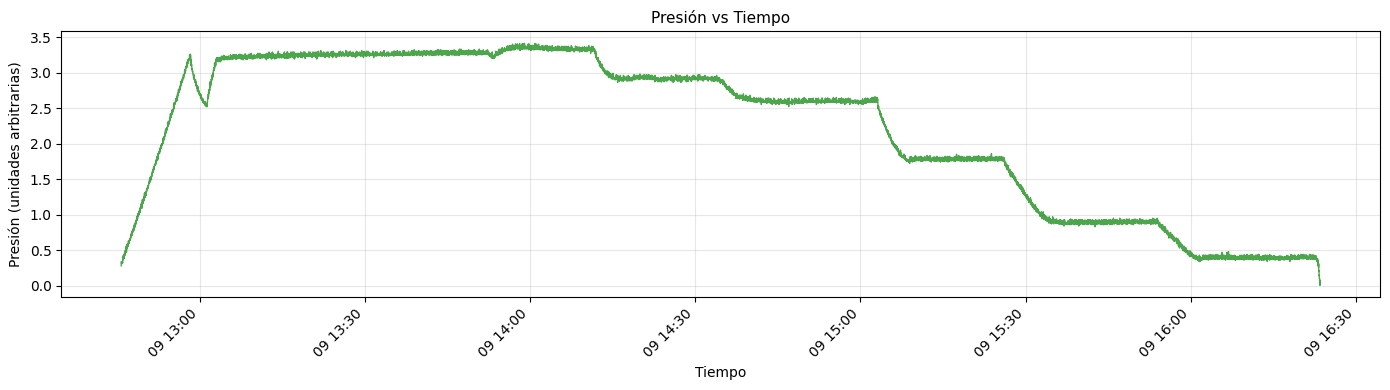

📊 Estadísticas de presión:
   Rango: [0.01, 3.41]
   Media: 2.23
   Std: 1.06
   Puntos válidos: 12,939


In [4]:
# Plot simple de presión vs tiempo (datos con problemas conocidos)
fig, ax = plt.subplots(1, 1, figsize=(14, 4))

# Extraer tiempos de presión y datos
times_press_raw = press_data["t"]
times_press = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times_press_raw])

# Verificar dimensiones de press_raw y seleccionar primer sensor si es necesario
if len(press_raw.shape) > 1:
    press_data_plot = press_raw[:, 0]  # Usar primer sensor de presión
else:
    press_data_plot = press_raw

# Filtrar valores positivos
press_valid_mask = press_data_plot > 0
times_press_valid = times_press[press_valid_mask]
press_valid = press_data_plot[press_valid_mask]

if len(press_valid) > 0:
    ax.plot(times_press_valid, press_valid, 'g-', linewidth=1.0, alpha=0.7)
    ax.set_xlabel('Tiempo', fontsize=10)
    ax.set_ylabel('Presión (unidades arbitrarias)', fontsize=10)
    ax.set_title('Presión vs Tiempo', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Rotar etiquetas del eje X
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
    
    plt.tight_layout()
    plt.show()
    
    print(f"📊 Estadísticas de presión:")
    print(f"   Rango: [{np.min(press_valid):.2f}, {np.max(press_valid):.2f}]")
    print(f"   Media: {np.mean(press_valid):.2f}")
    print(f"   Std: {np.std(press_valid):.2f}")
    print(f"   Puntos válidos: {len(press_valid):,}")
else:
    print("⚠️ No hay datos válidos de presión para mostrar")

## 3️⃣ Filtrar Rango Temporal (16:00-17:30)

In [5]:
# Usar times_all que ya incluye el TIME_SHIFT aplicado
times = times_all  # Ya tiene el shift de 2h aplicado

print(f"📅 Rango COMPLETO de datos disponible (wavelength con TIME_SHIFT aplicado):")
print(f"   Inicio: {times[0].strftime('%Y-%m-%d %H:%M:%S')}")
print(f"   Fin:    {times[-1].strftime('%Y-%m-%d %H:%M:%S')}")

# ============================================================================
# ⬅️ AJUSTA AQUÍ EL RANGO TEMPORAL QUE QUIERES ANALIZAR
# ============================================================================
# Opción A: Usar TODO el rango disponible
use_full_range = False  # Cambiar a True para analizar todos los datos

if use_full_range:
    t_inicio = times[0]
    t_fin = times[-1]
else:
    # Opción B: Definir rango específico manualmente
    # ⚠️ AJUSTA ESTOS VALORES según el rango que viste arriba
    fecha = datetime.date(2026, 6, 9)  # ⬅️ CAMBIAR según tu archivo (20260609.root)
    t_inicio = datetime.datetime.combine(fecha, datetime.time(13, 0))
    t_fin = datetime.datetime.combine(fecha, datetime.time(18, 0))

# Filtrar wavelength por rango temporal (ya tiene shift aplicado)
mask_time = (times >= t_inicio) & (times <= t_fin)
times_filtered = times[mask_time]
wav_filtered = wav_raw[mask_time]

# Filtrar temperatura usando sus propios tiempos (sin shift)
mask_time_temp = (times_temp >= t_inicio) & (times_temp <= t_fin)
temp_filtered = temp_raw[mask_time_temp]
times_temp_filtered = times_temp[mask_time_temp]

print(f"\n✅ Rango seleccionado para análisis:")
print(f"   {t_inicio.strftime('%Y-%m-%d %H:%M')} - {t_fin.strftime('%H:%M')}")
print(f"   Puntos en el rango: {len(times_filtered):,}")

if len(times_filtered) == 0:
    print(f"\n⚠️ ADVERTENCIA: No hay datos en el rango especificado!")
    print(f"\n💡 Soluciones:")
    print(f"   1. Cambia 'use_full_range = True' para usar todos los datos")
    print(f"   2. O ajusta 't_inicio' y 't_fin' según el rango disponible (ver arriba)")

📅 Rango COMPLETO de datos disponible (wavelength con TIME_SHIFT aplicado):
   Inicio: 2026-06-09 12:29:58
   Fin:    2026-06-09 16:35:47

✅ Rango seleccionado para análisis:
   2026-06-09 13:00 - 18:00
   Puntos en el rango: 1,615,860


## 4️⃣ Análisis de Temperatura (8 RTDs)

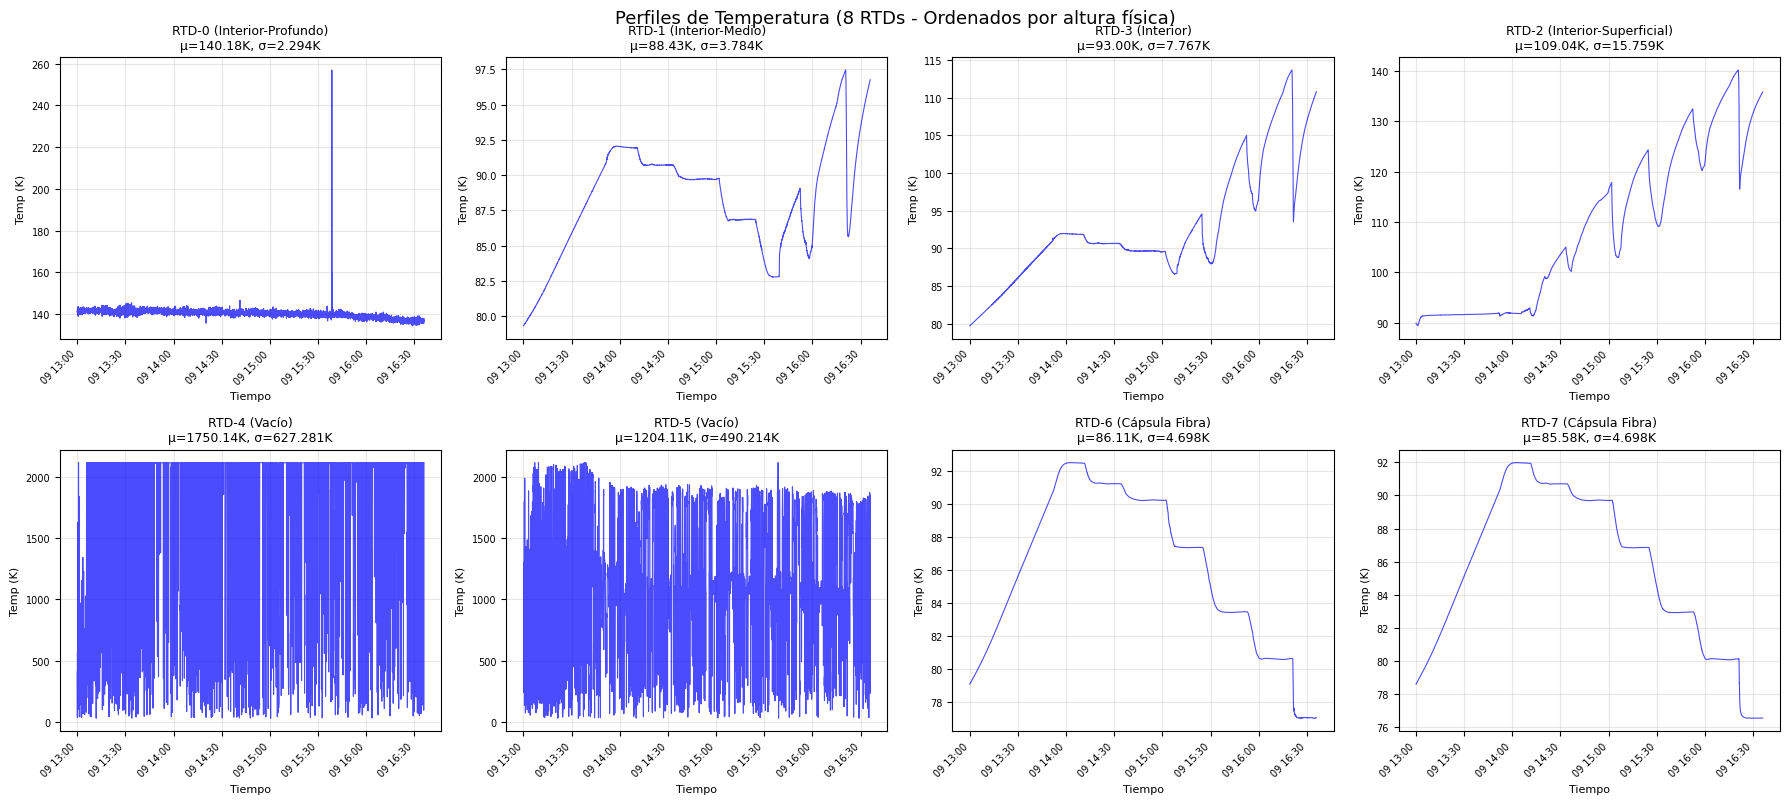


📊 Estadísticas (ordenados por altura física):
RTD-0 (Interior-Profundo)     : μ=140.18K  σ= 2.294K
RTD-1 (Interior-Medio)        : μ= 88.43K  σ= 3.784K
RTD-3 (Interior)              : μ= 93.00K  σ= 7.767K
RTD-2 (Interior-Superficial)  : μ=109.04K  σ=15.759K
RTD-4 (Vacío)                 : μ=1750.14K  σ=627.281K
RTD-5 (Vacío)                 : μ=1204.11K  σ=490.214K
RTD-6 (Cápsula Fibra)         : μ= 86.11K  σ= 4.698K
RTD-7 (Cápsula Fibra)         : μ= 85.58K  σ= 4.698K


In [6]:
# Configuración RTDs en orden de altura física (de abajo arriba en la vasija)
rtd_sensors_ordered = [
    (0, "RTD-0 (Interior-Profundo)"),      # Más cercano al suelo
    (1, "RTD-1 (Interior-Medio)"),         # Medio
    (3, "RTD-3 (Interior)"),               # Siguiente altura
    (2, "RTD-2 (Interior-Superficial)"),   # Más externo/superficial
    (4, "RTD-4 (Vacío)"),                  # Vacío
    (5, "RTD-5 (Vacío)"),                  # Vacío
    (6, "RTD-6 (Cápsula Fibra)"),          # Dentro de cápsula
    (7, "RTD-7 (Cápsula Fibra)")           # Dentro de cápsula
]

# Plot
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, (sensor_idx, sensor_name) in enumerate(rtd_sensors_ordered):
    temp_sensor = temp_filtered[:, sensor_idx]
    mask_valid = temp_sensor > 0
    times_valid = times_temp_filtered[mask_valid]
    temp_valid = temp_sensor[mask_valid]
    
    if len(temp_valid) > 0:
        axes[idx].plot(times_valid, temp_valid, 'b-', linewidth=0.8, alpha=0.7)
        axes[idx].set_title(f"{sensor_name}\nμ={np.mean(temp_valid):.2f}K, σ={np.std(temp_valid):.3f}K", fontsize=9)
        axes[idx].set_xlabel('Tiempo', fontsize=8)
        axes[idx].set_ylabel('Temp (K)', fontsize=8)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].tick_params(labelsize=7)
        for label in axes[idx].get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')

plt.tight_layout()
plt.suptitle('Perfiles de Temperatura (8 RTDs - Ordenados por altura física)', fontsize=13, y=1.00)
plt.show()

print("\n📊 Estadísticas (ordenados por altura física):")
for sensor_idx, sensor_name in rtd_sensors_ordered:
    temp_sensor = temp_filtered[:, sensor_idx]
    mask_valid = temp_sensor > 0
    temp_valid = temp_sensor[mask_valid]
    if len(temp_valid) > 0:
        print(f"{sensor_name:30s}: μ={np.mean(temp_valid):6.2f}K  σ={np.std(temp_valid):6.3f}K")

## 5️⃣ Procesamiento FBG: Filtrado y Media de Polarizaciones

### 5.1 Configuración de 4 Sensores FBG

In [7]:
# ⚠️ CONFIGURACIÓN: Solo 2 sensores funcionales
# 2 sensores × 2 polarizaciones = 4 canales
# Índices 0-based: sensor 0, 1 (Python indexing)
fbg_config = [
    {"pol": 0, "sensor": 0, "label": "FBG-1-P"},
    {"pol": 1, "sensor": 0, "label": "FBG-1-S"},
    {"pol": 0, "sensor": 1, "label": "FBG-2-P"},
    {"pol": 1, "sensor": 1, "label": "FBG-2-S"},
]

print(f"✅ Configurados {len(fbg_config)} canales FBG (2 sensores × 2 polarizaciones)")

✅ Configurados 4 canales FBG (2 sensores × 2 polarizaciones)


### 5.2 Filtrado Wavelength (μ±3σ)

In [8]:
def filter_wavelength_data(wav_data, timestamps, sigma_threshold=3.0):
    """Filtra wavelength usando método μ±3σ"""
    mask_positive = wav_data > 0
    wav_positive = wav_data[mask_positive]
    
    # Si no hay datos válidos, retornar estructura vacía
    if len(wav_positive) == 0:
        return {
            "timestamps": np.array([]),
            "wavelength": np.array([]),
            "mean": np.nan,
            "std": np.nan,
            "n_valid": 0
        }
    
    mean_wav = np.mean(wav_positive)
    std_wav = np.std(wav_positive)
    threshold_min = mean_wav - sigma_threshold * std_wav
    threshold_max = mean_wav + sigma_threshold * std_wav
    
    mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
    
    return {
        "timestamps": timestamps[mask_filtered],
        "wavelength": wav_data[mask_filtered],
        "mean": mean_wav,
        "std": std_wav,
        "n_valid": np.sum(mask_filtered)
    }

# DIAGNÓSTICO: Verificar forma y valores de los sensores
print(f"🔍 Forma de wav_filtered: {wav_filtered.shape}")
print(f"   Dimensiones: (time={wav_filtered.shape[0]}, pol={wav_filtered.shape[1]}, sensor={wav_filtered.shape[2]})")

# Diagnóstico por sensor (solo sensores funcionales: 0, 1)
print(f"\n🔍 Diagnóstico de valores por sensor (solo FBG-1, FBG-2):")
for sensor_idx in range(2):  # Solo 0, 1 (FBG-3 OMITIDO)
    for pol_idx in range(2):
        pol_name = "P" if pol_idx == 0 else "S"
        sensor_data = wav_filtered[:, pol_idx, sensor_idx]
        n_positive = np.sum(sensor_data > 0)
        if n_positive > 0:
            min_val = np.min(sensor_data[sensor_data > 0])
            max_val = np.max(sensor_data)
            mean_val = np.mean(sensor_data[sensor_data > 0])
        else:
            min_val = max_val = mean_val = 0
        
        print(f"   FBG-{sensor_idx+1}-{pol_name}: {n_positive:7d} pts > 0, range=[{min_val:.2f}, {max_val:.2f}] nm, μ={mean_val:.2f} nm")

# Procesar solo canales configurados (FBG-4 excluido)
fbg_filtered_data = {}
for cfg in fbg_config:
    wav_data = wav_filtered[:, cfg["pol"], cfg["sensor"]]  # (time, pol, sensor)
    fbg_filtered_data[cfg["label"]] = filter_wavelength_data(wav_data, times_filtered)

print("\n✅ Filtrado completado (solo sensores funcionales)")
print(f"\n{'Sensor':<12} {'Mean (nm)':<12} {'Std (nm)':<12} {'N válidos'}")
print("="*60)
for label, data in fbg_filtered_data.items():
    print(f"{label:<12} {data['mean']:<12.6f} {data['std']:<12.6f} {data['n_valid']}")

🔍 Forma de wav_filtered: (1615860, 2, 2)
   Dimensiones: (time=1615860, pol=2, sensor=2)

🔍 Diagnóstico de valores por sensor (solo FBG-1, FBG-2):
   FBG-1-P: 1615860 pts > 0, range=[1532.09, 1532.37] nm, μ=1532.25 nm
   FBG-1-S: 1615860 pts > 0, range=[1532.09, 1532.37] nm, μ=1532.25 nm
   FBG-2-P: 1615860 pts > 0, range=[1534.21, 1534.80] nm, μ=1534.60 nm
   FBG-2-S: 1615860 pts > 0, range=[1534.14, 1534.80] nm, μ=1534.65 nm

✅ Filtrado completado (solo sensores funcionales)

Sensor       Mean (nm)    Std (nm)     N válidos
FBG-1-P      1532.250436  0.084335     1615860
FBG-1-S      1532.250978  0.084180     1615860
FBG-2-P      1534.597154  0.127543     1615859
FBG-2-S      1534.653653  0.093462     1613800


In [9]:
# ============================================================================
# CELDA 1 y 2 UNIFICADAS: FILTRADO DE ENVOLVENTE SUPERIOR (PERCENTIL 90)
# ============================================================================
import numpy as np
import pandas as pd

def filter_wavelength_data_envelope(wav_data, timestamps, window_size=301, threshold_nm=0.035):
    """
    Filtro de envolvente superior. 
    Usa el percentil 90 para seguir siempre la "cresta" de los datos verdaderos,
    ignorando los bloques densos de caídas (outliers hacia abajo).
    """
    # 1. Conservar solo datos mayores a cero
    mask_positive = wav_data > 0
    wav_pos = wav_data[mask_positive]
    time_pos = timestamps[mask_positive]
    
    if len(wav_pos) == 0:
        return {
            "timestamps": np.array([]), "wavelength": np.array([]),
            "mean": np.nan, "std": np.nan, "n_valid": 0
        }
    
    # 2. Línea base dinámica usando el Percentil 90
    s = pd.Series(wav_pos)
    # Al usar quantile(0.90), obligamos a la línea base a pegarse a los valores altos (los reales).
    # Hemos subido el window_size a 301 para que la ventana sea más ancha que las caídas largas.
    rolling_baseline = s.rolling(window=window_size, center=True, min_periods=1).quantile(0.90)
    
    # 3. MÁSCARA ESTRICTA: Cortar todo lo que caiga por debajo de la envolvente
    # Se permite una pequeña tolerancia por encima y por debajo (threshold_nm) para el ruido natural.
    mask_filtered = (s >= rolling_baseline - threshold_nm) & (s <= rolling_baseline + threshold_nm)
    
    final_wav = wav_pos[mask_filtered]
    final_time = time_pos[mask_filtered]
    
    return {
        "timestamps": final_time,
        "wavelength": final_wav,
        "mean": np.mean(final_wav) if len(final_wav) > 0 else np.nan,
        "std": np.std(final_wav) if len(final_wav) > 0 else np.nan,
        "n_valid": len(final_wav)
    }

# --- EJECUCIÓN DEL FILTRADO SOBRE LOS CANALES CONFIGURADOS ---
fbg_filtered_data = {}
for cfg in fbg_config:
    wav_data = wav_filtered[:, cfg["pol"], cfg["sensor"]]  # Datos crudos
    
    # Llamamos al nuevo filtro de envolvente
    fbg_filtered_data[cfg["label"]] = filter_wavelength_data_envelope(wav_data, times_filtered)

print("✅ Filtrado de Envolvente Superior completado.")
for label, data in fbg_filtered_data.items():
    print(f"   {label}: {data['n_valid']} puntos válidos retenidos.")

✅ Filtrado de Envolvente Superior completado.
   FBG-1-P: 1615860 puntos válidos retenidos.
   FBG-1-S: 1615860 puntos válidos retenidos.
   FBG-2-P: 1329225 puntos válidos retenidos.
   FBG-2-S: 1603497 puntos válidos retenidos.


### 5.3 Calcular Media de Polarizaciones

In [10]:
# Calcular media P+S para cada sensor (solo sensores funcionales: 1, 2)
# FBG-3 omitido (sin datos)
fbg_mean_data = {}

for sensor_num in [1, 2]:  # Solo sensores funcionales (FBG-3 excluido)
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    label_mean = f"FBG-{sensor_num}-Mean"
    
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    
    times_p = data_p["timestamps"]
    times_s = data_s["timestamps"]
    wav_p = data_p["wavelength"]
    wav_s = data_s["wavelength"]
    
    # Verificar que hay datos válidos
    if len(times_p) == 0 or len(times_s) == 0:
        print(f"⚠️ FBG-{sensor_num} no tiene datos suficientes, omitiendo...")
        continue
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p])
    times_s_sec = np.array([t.timestamp() for t in times_s])
    wav_s_interp = np.interp(times_p_sec, times_s_sec, wav_s)
    
    # Media
    wav_mean = (wav_p + wav_s_interp) / 2.0
    
    fbg_mean_data[label_mean] = {
        "timestamps": times_p,
        "wavelength": wav_mean,
        "mean": np.mean(wav_mean),
        "std": np.std(wav_mean),
        "n_valid": len(wav_mean),
        "sensor_num": sensor_num
    }

print("✅ Medias calculadas (P+S)/2 para sensores funcionales")
print(f"\n{'Sensor':<15} {'Mean (nm)':<15} {'Std (nm)':<15} {'N puntos'}")
print("="*65)
for label, data in fbg_mean_data.items():
    print(f"{label:<15} {data['mean']:<15.6f} {data['std']:<15.6f} {data['n_valid']}")

✅ Medias calculadas (P+S)/2 para sensores funcionales

Sensor          Mean (nm)       Std (nm)        N puntos
FBG-1-Mean      1532.250707     0.084255        1615860
FBG-2-Mean      1534.640827     0.092233        1329225


### 5.4 Visualizar Wavelengths (Media de Polarizaciones)

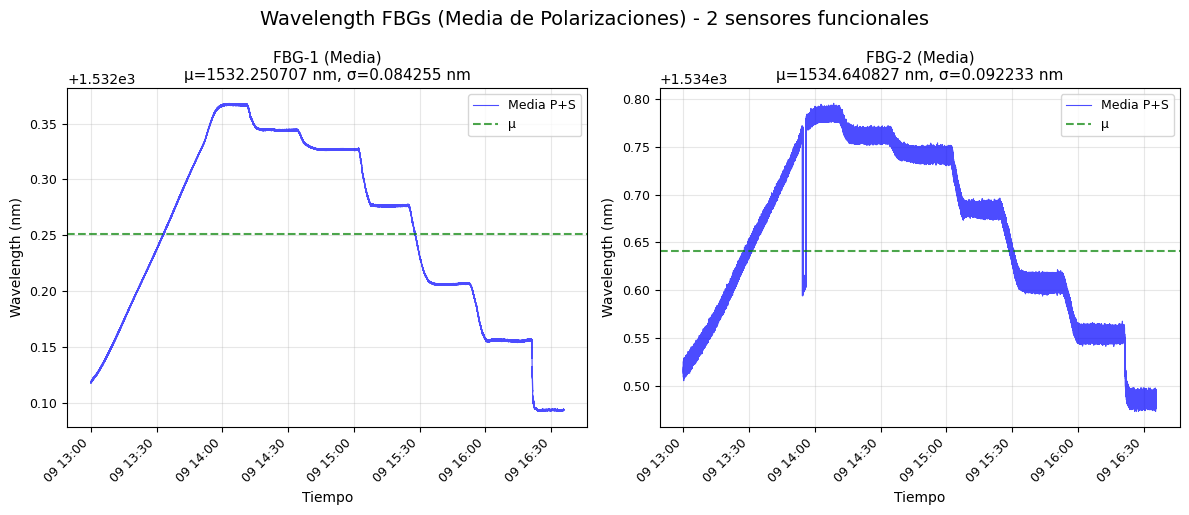

In [11]:
# Ajustar layout para 2 sensores (FBG-3 omitido)
n_sensors = len(fbg_mean_data)
if n_sensors == 2:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
elif n_sensors == 4:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
else:
    fig, axes = plt.subplots(1, n_sensors, figsize=(6*n_sensors, 5))

if n_sensors == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, (label, data) in enumerate(fbg_mean_data.items()):
    times_fbg = data["timestamps"]
    wav_fbg = data["wavelength"]
    sensor_num = data["sensor_num"]
    
    axes[idx].plot(times_fbg, wav_fbg, 'b-', linewidth=0.8, alpha=0.7, label='Media P+S')
    axes[idx].axhline(data['mean'], color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='μ')
    
    axes[idx].set_title(f"FBG-{sensor_num} (Media)\nμ={data['mean']:.6f} nm, σ={data['std']:.6f} nm", fontsize=11)
    axes[idx].set_xlabel('Tiempo', fontsize=10)
    axes[idx].set_ylabel('Wavelength (nm)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=9)
    axes[idx].tick_params(labelsize=9)
    
    for tick_label in axes[idx].get_xticklabels():
        tick_label.set_rotation(45)
        tick_label.set_ha('right')

plt.tight_layout()
plt.suptitle(f'Wavelength FBGs (Media de Polarizaciones) - {n_sensors} sensores funcionales', fontsize=14, y=1.02)
plt.show()

## 6️⃣ Correlación Temperatura - Wavelength

### 6.1 Seleccionar RTD de Referencia

In [12]:
# Usar RTD-8 (cápsula fibra) como referencia
rtd_ref_idx = 7  # RTD-8 (cápsula fibra) es el sensor 7 (índice 7 en Python)
rtd_ref_name = "RTD-8 (Cápsula)"

temp_ref = temp_filtered[:, rtd_ref_idx]
mask_temp_valid = temp_ref > 0
times_temp_ref = times_temp_filtered[mask_temp_valid]
temp_ref_valid = temp_ref[mask_temp_valid]

print(f"✅ Referencia: {rtd_ref_name}")
print(f"   Rango: [{np.min(temp_ref_valid):.2f}, {np.max(temp_ref_valid):.2f}] K")

✅ Referencia: RTD-8 (Cápsula)
   Rango: [76.53, 91.98] K


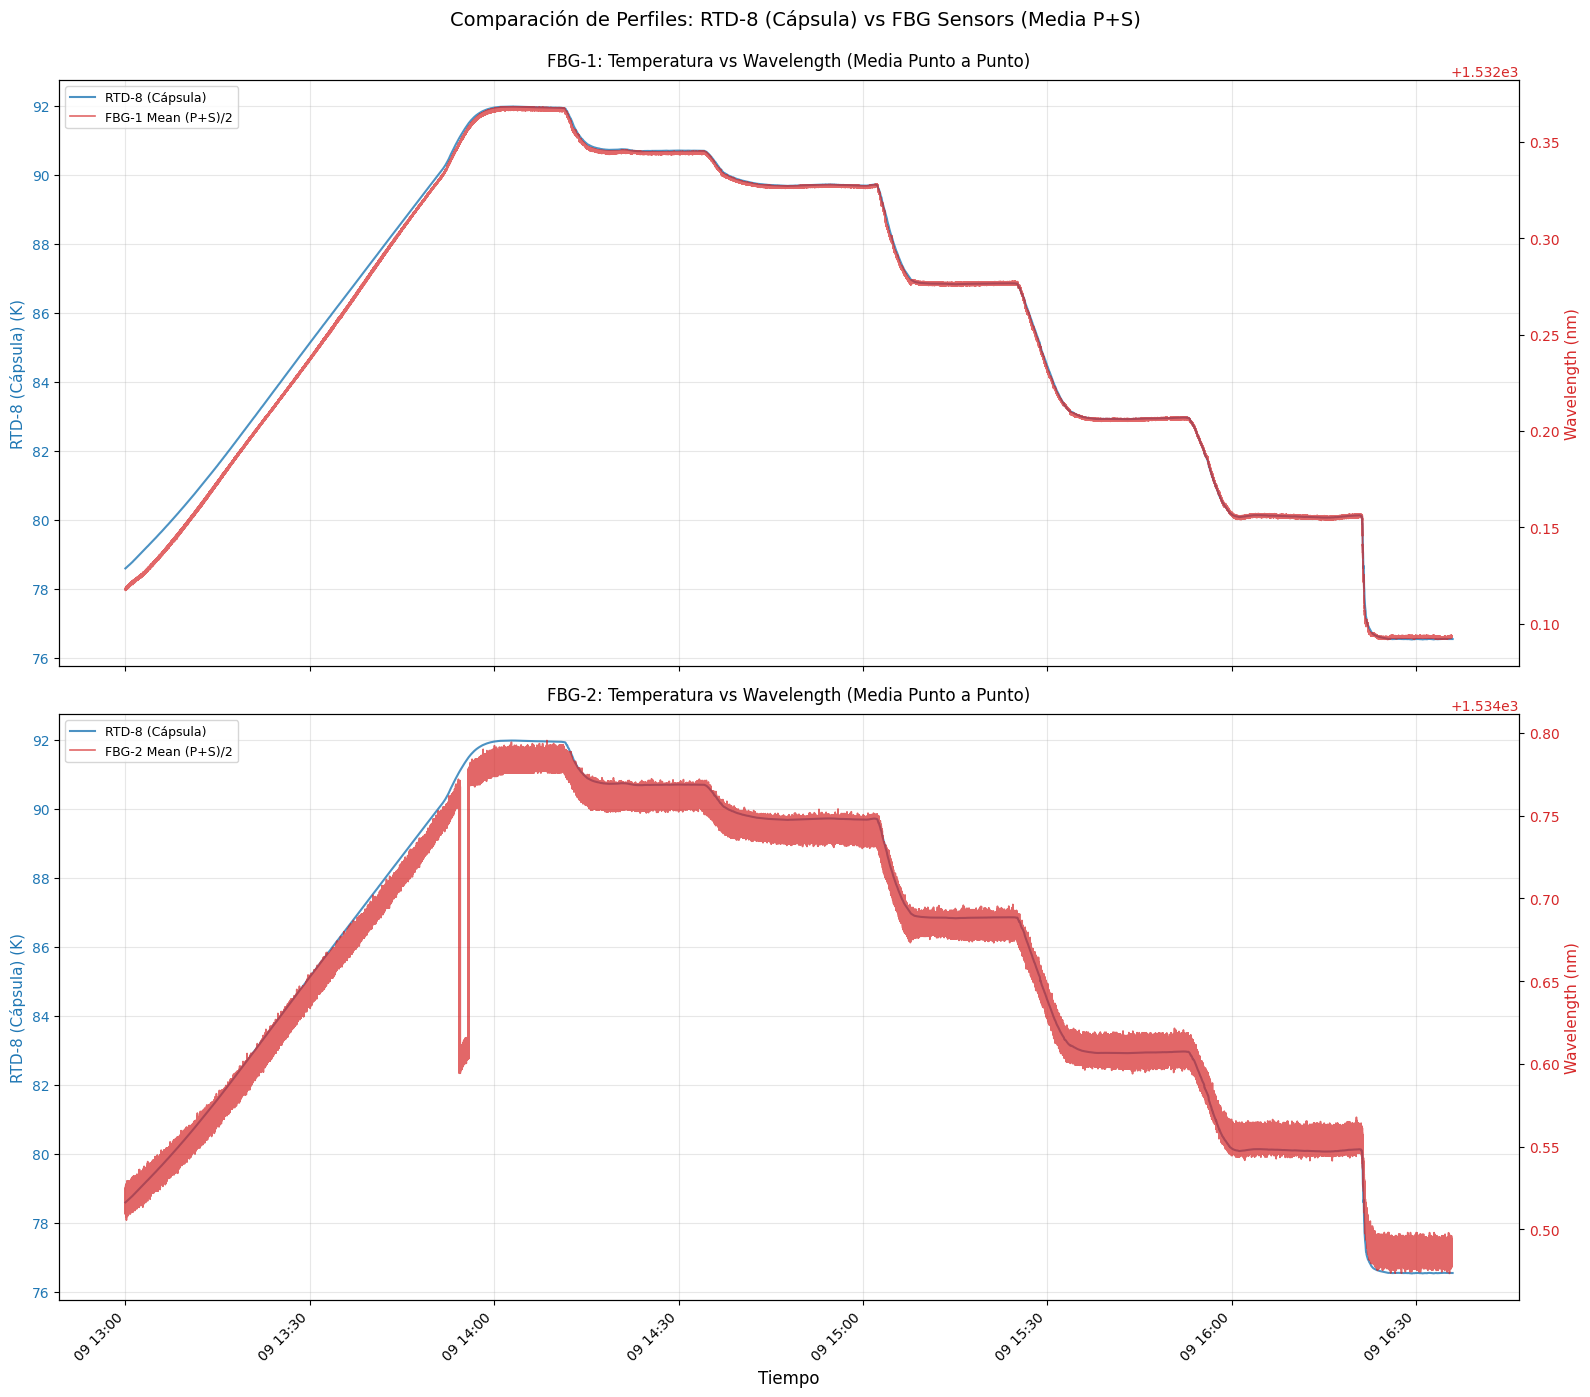

✅ Gráficos superpuestos generados para 2 sensores FBG
   💡 Ejecuta primero la celda 6.3 para ver los plateaus marcados


In [13]:
# Superposición de temperatura con cada sensor FBG (2 subplots)
fig, axes = plt.subplots(2, 1, figsize=(16, 14), sharex=True)

color_temp = 'tab:blue'
color_wav = 'tab:red'

for idx, sensor_num in enumerate([1, 2]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    fbg_data_plot = fbg_mean_data[fbg_label]
    
    ax1 = axes[idx]
    
    # Eje izquierdo: Temperatura
    ax1.set_ylabel(f'{rtd_ref_name} (K)', fontsize=11, color=color_temp)
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.5, alpha=0.8, label=rtd_ref_name)
    ax1.tick_params(axis='y', labelcolor=color_temp)
    ax1.grid(True, alpha=0.3, axis='both')
    
    # Marcar plateaus con líneas verticales (si están definidos)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for plateau in plateau_data:
            ax1.axvline(plateau["t0"], color='red', linestyle='--', linewidth=1.5, alpha=0.6)
            ax1.axvline(plateau["tfin"], color='blue', linestyle='--', linewidth=1.5, alpha=0.6)
    
    # Eje derecho: Wavelength (media punto a punto P+S)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=11, color=color_wav)
    ax2.plot(fbg_data_plot["timestamps"], fbg_data_plot["wavelength"], 
             color=color_wav, linewidth=1.2, alpha=0.7, 
             label=f'FBG-{sensor_num} Mean (P+S)/2')
    ax2.tick_params(axis='y', labelcolor=color_wav)
    
    # Leyendas combinadas
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    
    # Añadir leyenda para plateaus si existen
    if 'plateau_data' in globals() and len(plateau_data) > 0 and idx == 0:
        from matplotlib.lines import Line2D
        custom_lines = [Line2D([0], [0], color='red', linestyle='--', linewidth=1.5),
                       Line2D([0], [0], color='blue', linestyle='--', linewidth=1.5)]
        ax1.legend(lines1 + lines2 + custom_lines, 
                  labels1 + labels2 + ['Inicio plateau', 'Fin plateau'], 
                  loc='upper left', fontsize=9)
    else:
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    # Título del subplot
    ax1.set_title(f'FBG-{sensor_num}: Temperatura vs Wavelength (Media Punto a Punto)', 
                  fontsize=12, pad=10)

# Solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=12)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Comparación de Perfiles: {rtd_ref_name} vs FBG Sensors (Media P+S)', 
             fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

print(f"✅ Gráficos superpuestos generados para 2 sensores FBG")
if 'plateau_data' in globals() and len(plateau_data) > 0:
    print(f"   🔴🔵 Plateaus marcados con líneas verticales (rojo=inicio, azul=fin)")
else:
    print(f"   💡 Ejecuta primero la celda 6.3 para ver los plateaus marcados")

### 6.2 Visualización de Perfiles (para definir plateaus)

Superposición de temperatura y wavelength para identificar visualmente los plateaus.

### 6.3 Definición Manual de Plateaus

**✏️ Define aquí los intervalos temporales de plateau identificados en los gráficos anteriores**

In [14]:
# ============================================================================
# DEFINICIÓN MANUAL DE PLATEAUS (basados en los gráficos de la sección 6.2)
# ============================================================================
# Formato: [("Nombre", "HH:MM", "HH:MM"), ...]

manual_plateaus = [
    ("Plateau 1", "14:00", "14:11"),
    ("Plateau 2", "14:22", "14:33"),
    ("Plateau 3", "14:50", "15:01"),
    ("Plateau 4", "15:12", "15:23"),
    ("Plateau 5", "15:40", "15:51"),
    ("Plateau 6", "16:08", "16:19"),
    ("Plateau 7", "16:24", "16:35"),
]

# Activar plateaus manuales
use_manual_plateaus = True

# Procesar plateaus
plateau_data = []

if use_manual_plateaus and len(manual_plateaus) > 0:
    print("✅ Usando plateaus manuales:")
    print("="*70)
    
    for name, t0_str, tfin_str in manual_plateaus:
        t0 = datetime.datetime.combine(fecha, datetime.datetime.strptime(t0_str, "%H:%M").time())
        tfin = datetime.datetime.combine(fecha, datetime.datetime.strptime(tfin_str, "%H:%M").time())
        
        # Calcular media y std de temperatura en el plateau
        mask_temp_plateau = (times_temp_ref >= t0) & (times_temp_ref <= tfin)
        temp_plateau = temp_ref_valid[mask_temp_plateau]
        
        if len(temp_plateau) > 0:
            temp_mean = np.mean(temp_plateau)
            temp_std = np.std(temp_plateau)
            
            plateau_info = {
                "name": name,
                "t0": t0,
                "tfin": tfin,
                "temp_mean": temp_mean,
                "temp_std": temp_std,
                "n_temp_points": len(temp_plateau)
            }
            
            plateau_data.append(plateau_info)
            
            print(f"{name}: {t0_str} - {tfin_str}")
            print(f"  Temperatura: μ={temp_mean:.3f}K, σ={temp_std:.4f}K, n={len(temp_plateau)}")
        else:
            print(f"⚠️ {name}: No hay datos de temperatura en este rango")
    
    print("="*70)
    print(f"\n✅ {len(plateau_data)} plateaus definidos")
else:
    print("ℹ️ Plateaus desactivados")

✅ Usando plateaus manuales:
Plateau 1: 14:00 - 14:11
  Temperatura: μ=91.967K, σ=0.0109K, n=330
Plateau 2: 14:22 - 14:33
  Temperatura: μ=90.701K, σ=0.0060K, n=331
Plateau 3: 14:50 - 15:01
  Temperatura: μ=89.707K, σ=0.0105K, n=331
Plateau 4: 15:12 - 15:23
  Temperatura: μ=86.844K, σ=0.0067K, n=331
Plateau 5: 15:40 - 15:51
  Temperatura: μ=82.930K, σ=0.0116K, n=326
Plateau 6: 16:08 - 16:19
  Temperatura: μ=80.082K, σ=0.0141K, n=330
Plateau 7: 16:24 - 16:35
  Temperatura: μ=76.541K, σ=0.0132K, n=330

✅ 7 plateaus definidos


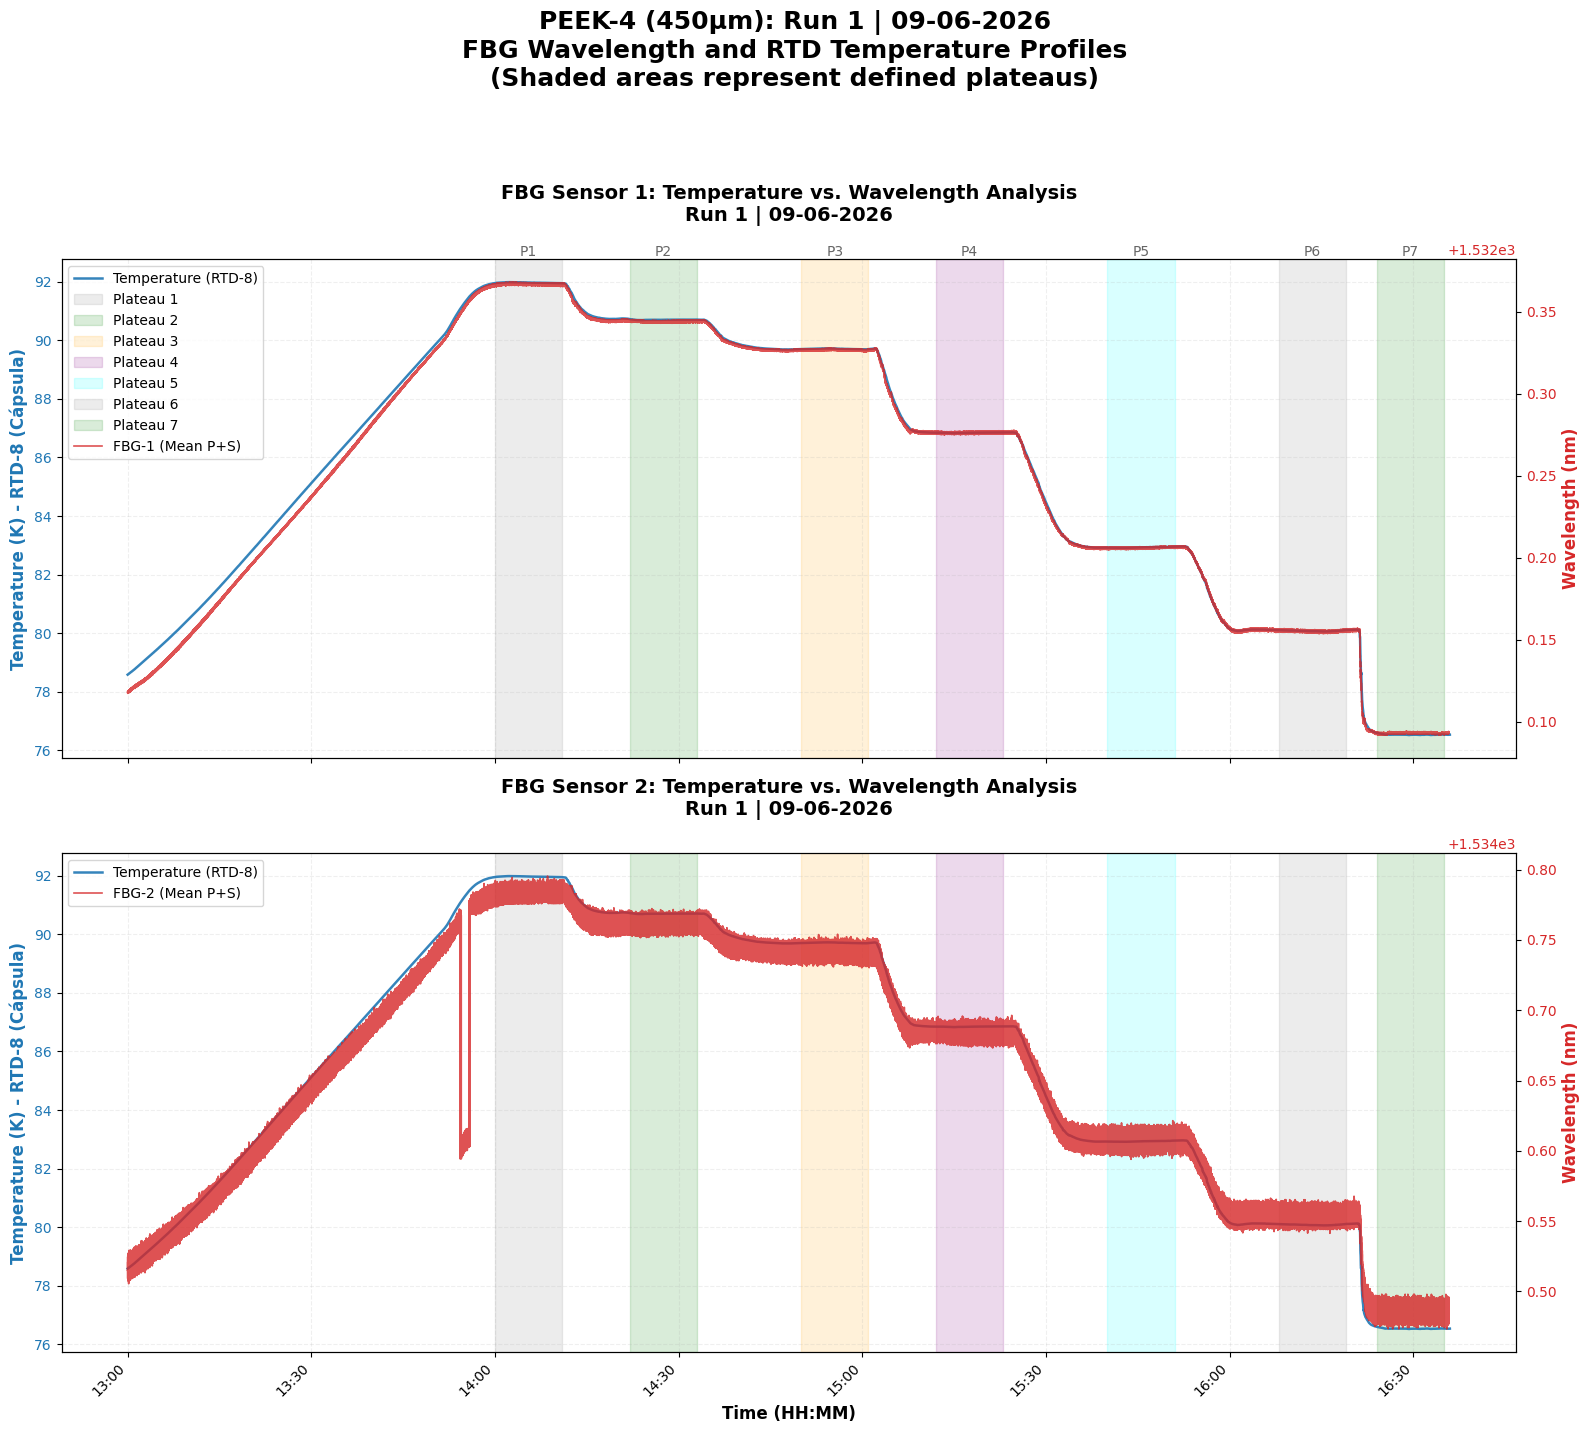

✅ Plot generated with English labels and shaded plateaus.


In [15]:
# ============================================================================
# PLOT: Wavelength vs Temperature with Shaded Plateaus (English)
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Configuration
color_temp = 'tab:blue'
color_wav = 'tab:red'
# Colors for the plateau shaded areas
plateau_colors = ['gray', 'green', 'orange', 'purple', 'cyan']

fig, axes = plt.subplots(2, 1, figsize=(16, 14), sharex=True)

for idx, sensor_num in enumerate([1, 2]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    if fbg_label not in fbg_mean_data:
        continue
        
    fbg_data_plot = fbg_mean_data[fbg_label]
    ax1 = axes[idx]
    
    # 1. Left Axis: Temperature (RTD-6 Capsule)
    ax1.set_ylabel(f'Temperature (K) - {rtd_ref_name}', fontsize=12, color=color_temp, fontweight='bold')
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.8, alpha=0.9, label='Temperature (RTD-8)')
    ax1.tick_params(axis='y', labelcolor=color_temp)
    ax1.grid(True, alpha=0.2, linestyle='--')
    
    # 2. Add Shaded Plateaus
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for p_idx, plateau in enumerate(plateau_data):
            p_color = plateau_colors[p_idx % len(plateau_colors)]
            ax1.axvspan(plateau["t0"], plateau["tfin"], 
                        color=p_color, alpha=0.15, 
                        label=f'Plateau {p_idx+1}' if idx == 0 else "")
            # Optional: Add text label on top of the shaded area
            if idx == 0:
                mid_time = plateau["t0"] + (plateau["tfin"] - plateau["t0"]) / 2
                ax1.text(mid_time, ax1.get_ylim()[1], f'P{p_idx+1}', 
                         ha='center', va='bottom', fontsize=10, color='black', alpha=0.6)

    # 3. Right Axis: Wavelength
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=12, color=color_wav, fontweight='bold')
    ax2.plot(fbg_data_plot["timestamps"], fbg_data_plot["wavelength"], 
             color=color_wav, linewidth=1.2, alpha=0.8, 
             label=f'FBG-{sensor_num} (Mean P+S)')
    ax2.tick_params(axis='y', labelcolor=color_wav)
    
    # Titles and Legends
    ax1.set_title(f'FBG Sensor {sensor_num}: Temperature vs. Wavelength Analysis\nRun 1 | 09-06-2026', 
                  fontsize=14, pad=28, fontweight='bold')
    
    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, framealpha=0.8)

# Format X-Axis (Time)
axes[-1].set_xlabel('Time (HH:MM)', fontsize=12, fontweight='bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

# Shared Layout
plt.suptitle('PEEK-4 (450µm): Run 1 | 09-06-2026\nFBG Wavelength and RTD Temperature Profiles\n(Shaded areas represent defined plateaus)', 
             fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.975])
plt.show()

print("✅ Plot generated with English labels and shaded plateaus.")

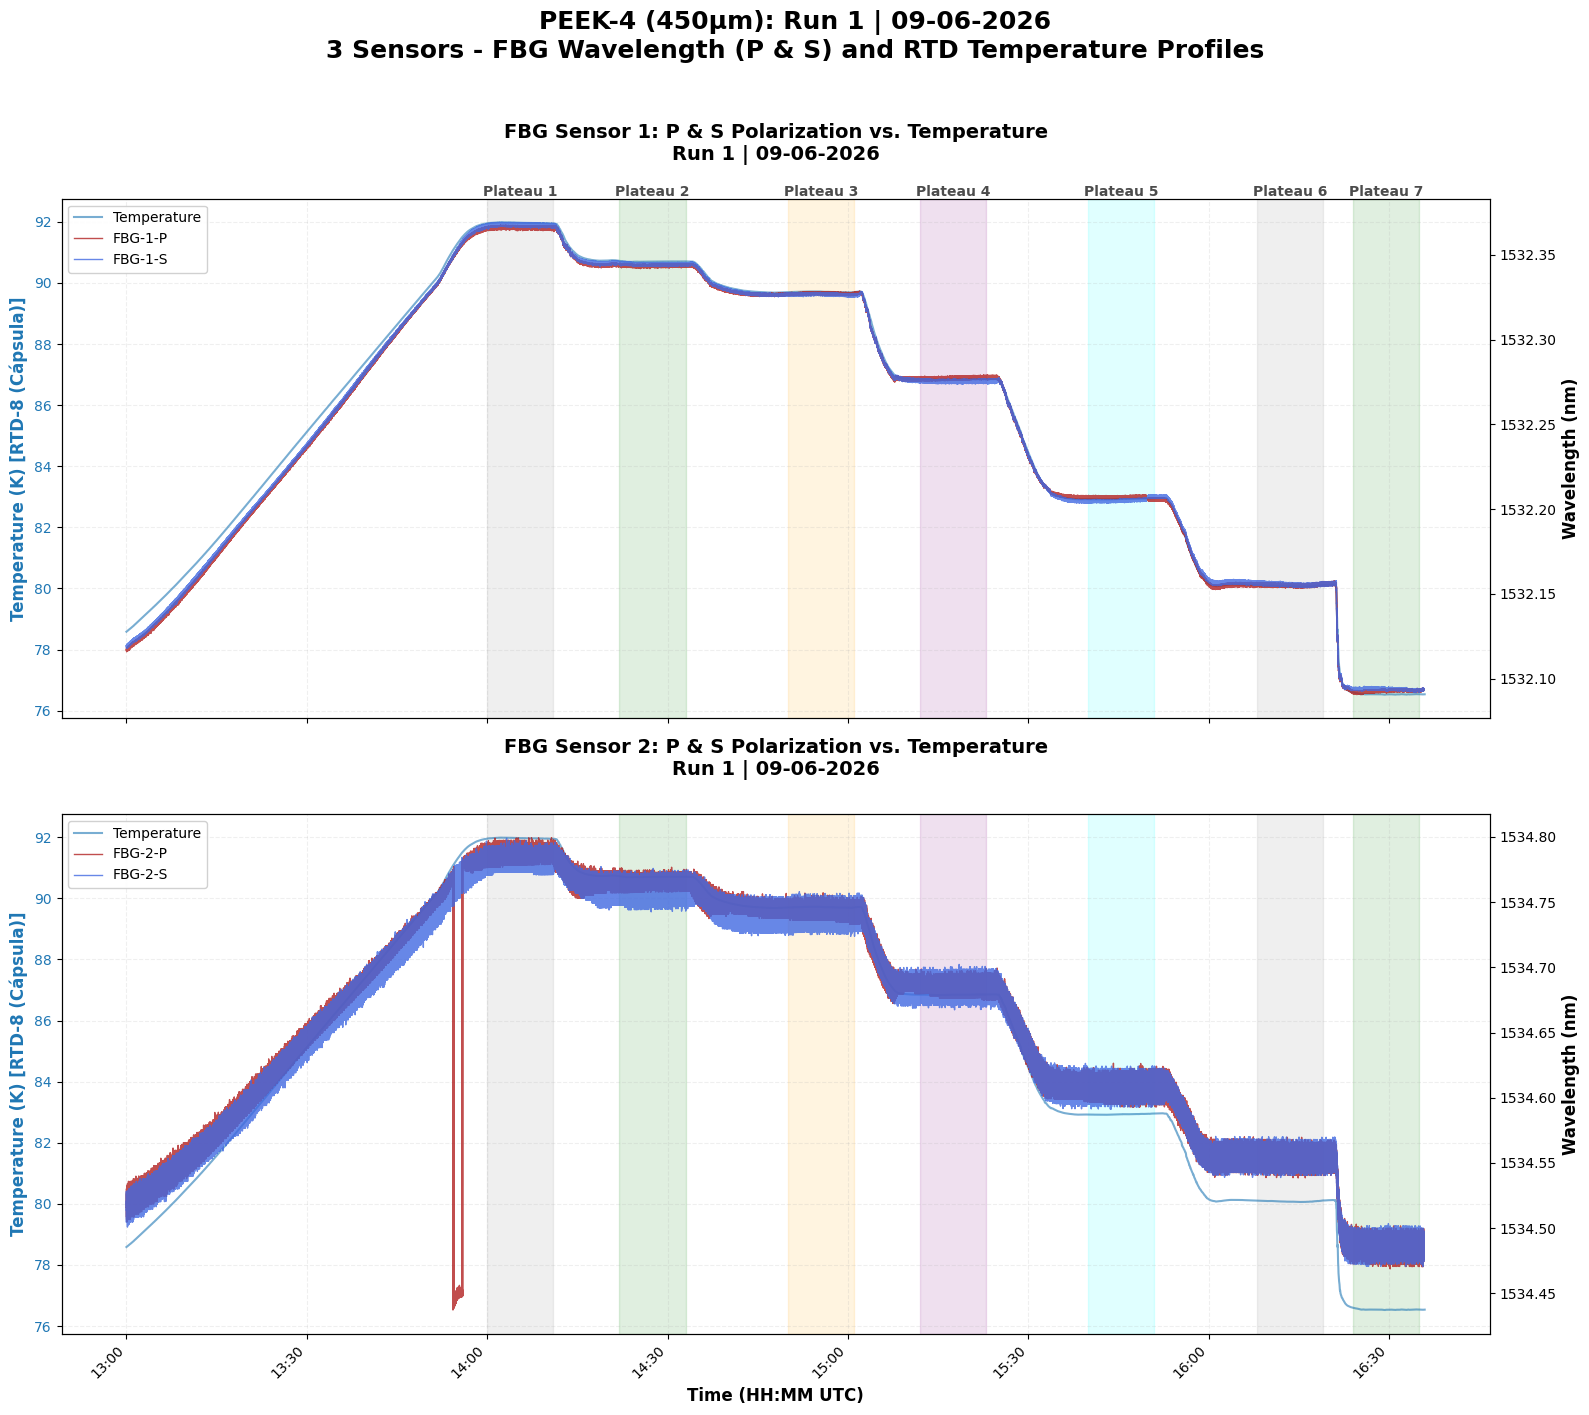

✅ Superimposed polarization plot generated.


In [16]:
# ============================================================================
# PLOT: Dual Polarization (P & S) vs Temperature with Shaded Plateaus
# Fiber: PEEK-4 (450µm) | Run 1 | 09-06-2026
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Configuration
color_temp = 'tab:blue'
color_pol_p = 'firebrick'   # Color for Polarization P
color_pol_s = 'royalblue'   # Color for Polarization S
plateau_colors = ['gray', 'green', 'orange', 'purple', 'cyan']

fig, axes = plt.subplots(2, 1, figsize=(16, 15), sharex=True)

for idx, sensor_num in enumerate([1, 2]):
    # Labels for both polarizations
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    
    if label_p not in fbg_filtered_data or label_s not in fbg_filtered_data:
        print(f"⚠️ Data missing for {label_p} or {label_s}, skipping...")
        continue
        
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    ax1 = axes[idx]
    
    # 1. Left Axis: Temperature (RTD Reference)
    ax1.set_ylabel(f'Temperature (K) [{rtd_ref_name}]', fontsize=12, color=color_temp, fontweight='bold')
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.5, alpha=0.6, label='Temperature')
    ax1.tick_params(axis='y', labelcolor=color_temp)
    ax1.grid(True, alpha=0.2, linestyle='--')
    
    # 2. Add Shaded Plateaus (Color bands)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for p_idx, plateau in enumerate(plateau_data):
            p_color = plateau_colors[p_idx % len(plateau_colors)]
            ax1.axvspan(plateau["t0"], plateau["tfin"], 
                        color=p_color, alpha=0.12)
            # Label plateaus at the top of the first subplot
            if idx == 0:
                mid_time = plateau["t0"] + (plateau["tfin"] - plateau["t0"]) / 2
                ax1.text(mid_time, ax1.get_ylim()[1], f'Plateau {p_idx+1}', 
                         ha='center', va='bottom', fontsize=10, fontweight='bold', alpha=0.7)

    # 3. Right Axis: Wavelength (Superimposed Polarizations)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=12, color='black', fontweight='bold')
    
    # Plot P Polarization
    ax2.plot(data_p["timestamps"], data_p["wavelength"], 
             color=color_pol_p, linewidth=1.0, alpha=0.8, label=f'FBG-{sensor_num}-P')
    
    # Plot S Polarization
    ax2.plot(data_s["timestamps"], data_s["wavelength"], 
             color=color_pol_s, linewidth=1.0, alpha=0.8, label=f'FBG-{sensor_num}-S')
    
    ax2.tick_params(axis='y', labelcolor='black')
    ax2.ticklabel_format(useOffset=False, axis='y') # Crucial to see pm changes
    
    # Titles and Legends
    ax1.set_title(f'FBG Sensor {sensor_num}: P & S Polarization vs. Temperature\nRun 1 | 09-06-2026',                  fontsize=14, pad=28, fontweight='bold')
    
    # Merge legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, framealpha=0.9)

# Format X-Axis (Time)
axes[-1].set_xlabel('Time (HH:MM UTC)', fontsize=12, fontweight='bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

# Overall Figure Title
plt.suptitle('PEEK-4 (450µm): Run 1 | 09-06-2026\n3 Sensors - FBG Wavelength (P & S) and RTD Temperature Profiles', 
             fontsize=18, y=0.97, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("✅ Superimposed polarization plot generated.")

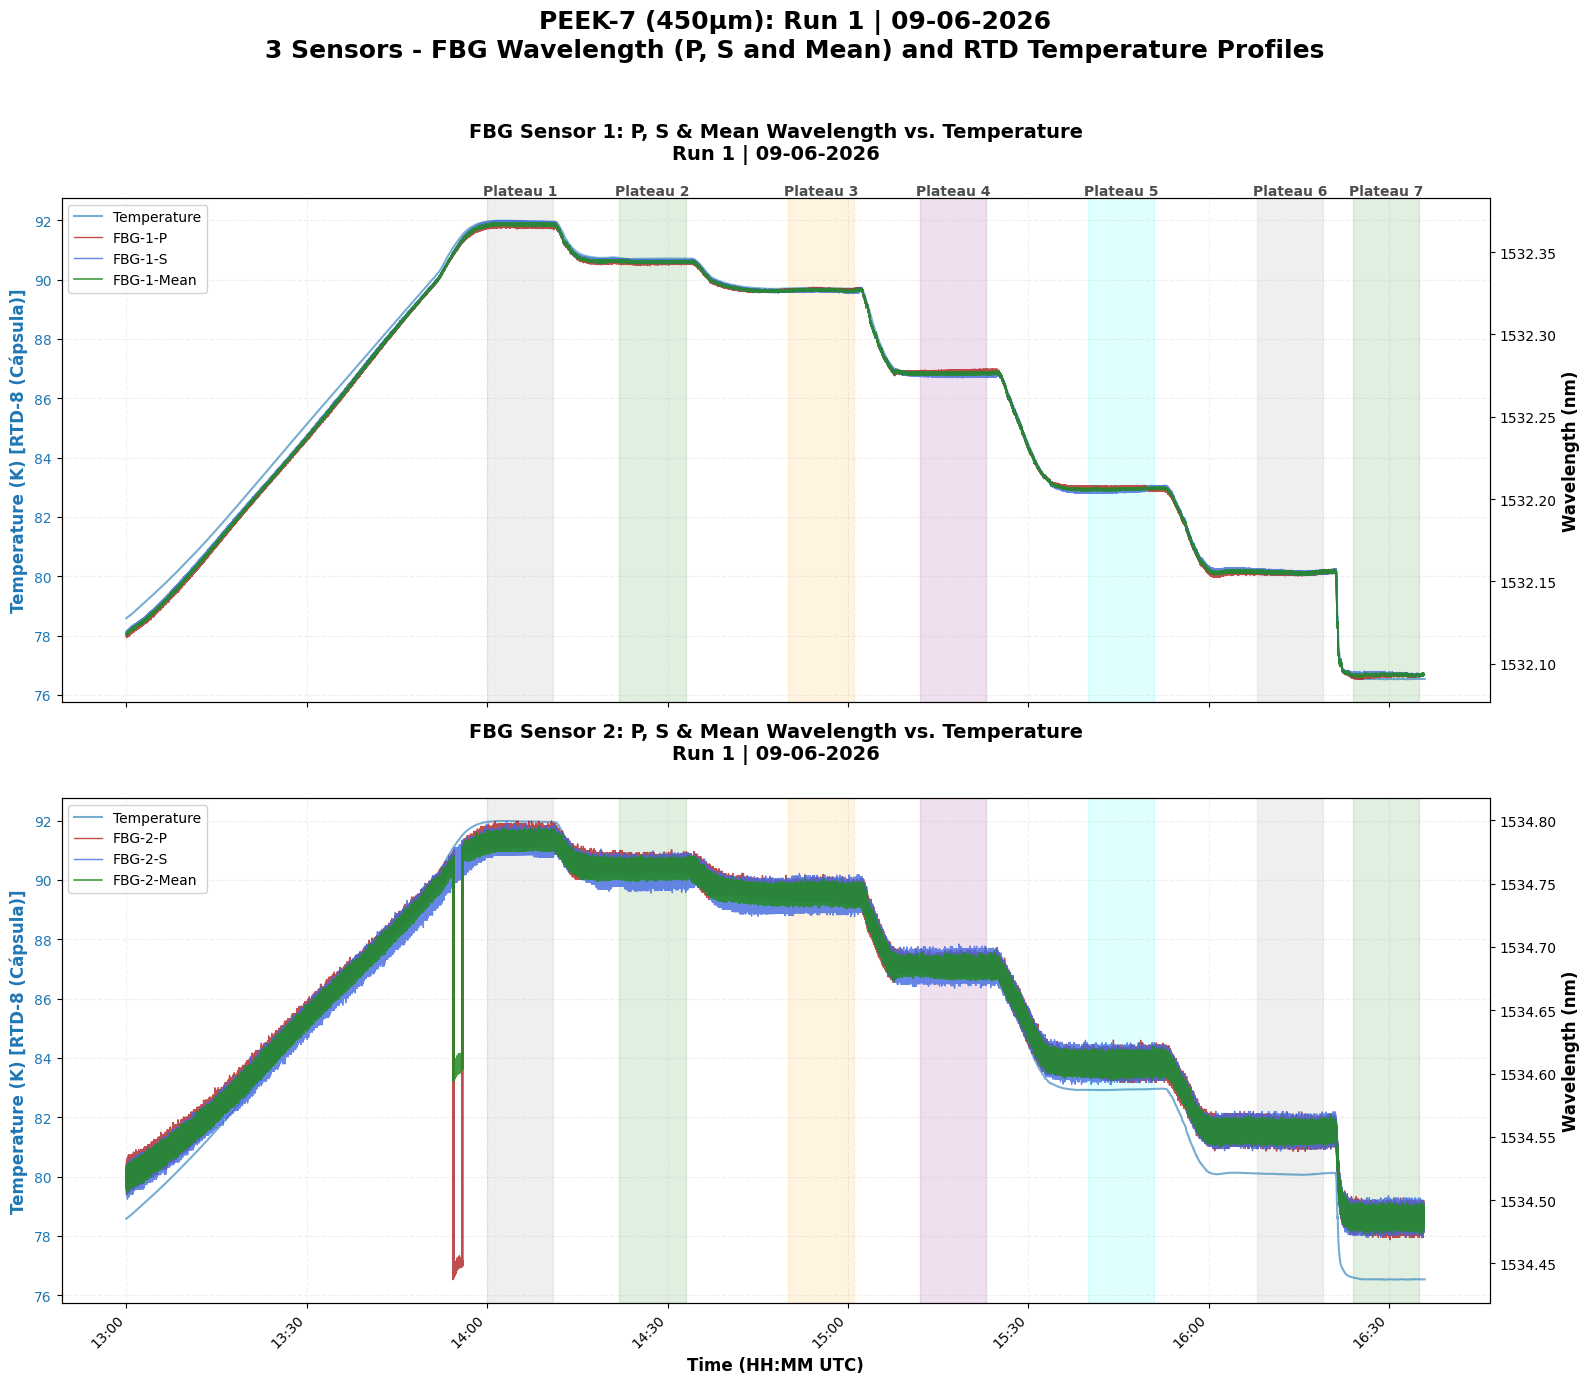

✅ Combined P/S/Mean plot generated.


In [17]:
# ============================================================================
# PLOT: P, S y Media vs Temperatura con Plateaus Sombreados
# Fiber: PEEK-4 (450µm) | Run 1 | 09-06-2026
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Configuration
color_temp = 'tab:blue'
color_pol_p = 'firebrick'   # Color for Polarization P
color_pol_s = 'royalblue'   # Color for Polarization S
color_pol_mean = 'forestgreen'  # Color for Mean (P+S)/2
plateau_colors = ['gray', 'green', 'orange', 'purple', 'cyan']

fig, axes = plt.subplots(2, 1, figsize=(16, 15), sharex=True)

for idx, sensor_num in enumerate([1, 2]):
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    label_mean = f"FBG-{sensor_num}-Mean"

    if (
        label_p not in fbg_filtered_data or
        label_s not in fbg_filtered_data or
        label_mean not in fbg_mean_data
    ):
        print(f"⚠️ Data missing for {label_p}, {label_s} or {label_mean}, skipping...")
        continue

    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    data_mean = fbg_mean_data[label_mean]
    ax1 = axes[idx]

    # 1. Left Axis: Temperature (RTD Reference)
    ax1.set_ylabel(f'Temperature (K) [{rtd_ref_name}]', fontsize=12, color=color_temp, fontweight='bold')
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.5, alpha=0.6, label='Temperature')
    ax1.tick_params(axis='y', labelcolor=color_temp)
    ax1.grid(True, alpha=0.2, linestyle='--')

    # 2. Add Shaded Plateaus (Color bands)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for p_idx, plateau in enumerate(plateau_data):
            p_color = plateau_colors[p_idx % len(plateau_colors)]
            ax1.axvspan(plateau["t0"], plateau["tfin"], color=p_color, alpha=0.12)
            if idx == 0:
                mid_time = plateau["t0"] + (plateau["tfin"] - plateau["t0"]) / 2
                ax1.text(mid_time, ax1.get_ylim()[1], f'Plateau {p_idx+1}',
                         ha='center', va='bottom', fontsize=10, fontweight='bold', alpha=0.7)

    # 3. Right Axis: Wavelength (P, S and Mean)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=12, color='black', fontweight='bold')

    ax2.plot(data_p["timestamps"], data_p["wavelength"],
             color=color_pol_p, linewidth=1.0, alpha=0.8, label=f'FBG-{sensor_num}-P')
    ax2.plot(data_s["timestamps"], data_s["wavelength"],
             color=color_pol_s, linewidth=1.0, alpha=0.8, label=f'FBG-{sensor_num}-S')
    ax2.plot(data_mean["timestamps"], data_mean["wavelength"],
             color=color_pol_mean, linewidth=1.2, alpha=0.85, label=f'FBG-{sensor_num}-Mean')

    ax2.tick_params(axis='y', labelcolor='black')
    ax2.ticklabel_format(useOffset=False, axis='y')

    # Titles and Legends
    ax1.set_title(f'FBG Sensor {sensor_num}: P, S & Mean Wavelength vs. Temperature\nRun 1 | 09-06-2026',
                  fontsize=14, pad=28, fontweight='bold')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, framealpha=0.9)

# Format X-Axis (Time)
axes[-1].set_xlabel('Time (HH:MM UTC)', fontsize=12, fontweight='bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

# Overall Figure Title
plt.suptitle('PEEK-7 (450µm): Run 1 | 09-06-2026\n3 Sensors - FBG Wavelength (P, S and Mean) and RTD Temperature Profiles',
             fontsize=18, y=0.95, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

print("✅ Combined P/S/Mean plot generated.")

### 6.4 Calcular Sensibilidad por Plateaus

Calcula la media y std de wavelength en cada plateau para cada sensor FBG.

In [18]:
# Calcular media y std de wavelength por plateau para cada sensor
plateau_sensitivity_data = {}

for fbg_label, fbg_data in fbg_mean_data.items():
    sensor_num = fbg_data["sensor_num"]
    fbg_times = fbg_data["timestamps"]
    fbg_wav = fbg_data["wavelength"]
    
    plateau_wav_stats = []
    
    for plateau in plateau_data:
        # Máscara para datos de wavelength en este plateau
        mask_wav_plateau = (fbg_times >= plateau["t0"]) & (fbg_times <= plateau["tfin"])
        wav_plateau = fbg_wav[mask_wav_plateau]
        
        if len(wav_plateau) > 0:
            wav_mean = np.mean(wav_plateau)
            wav_std = np.std(wav_plateau)
            
            plateau_wav_stats.append({
                "name": plateau["name"],
                "temp_mean": plateau["temp_mean"],
                "temp_std": plateau["temp_std"],
                "wav_mean": wav_mean,
                "wav_std": wav_std,
                "n_wav_points": len(wav_plateau)
            })
    
    plateau_sensitivity_data[fbg_label] = plateau_wav_stats

print("✅ Estadísticas de wavelength calculadas por plateau")
print("\nResumen por sensor:")
print("="*80)
for fbg_label in fbg_mean_data.keys():
    sensor_num = fbg_mean_data[fbg_label]["sensor_num"]
    n_plateaus = len(plateau_sensitivity_data[fbg_label])
    print(f"FBG-{sensor_num}: {n_plateaus} plateaus procesados")

✅ Estadísticas de wavelength calculadas por plateau

Resumen por sensor:
FBG-1: 7 plateaus procesados
FBG-2: 7 plateaus procesados


### 6.5 Visualizar Sensibilidad (Temp vs Wavelength con barras de error)

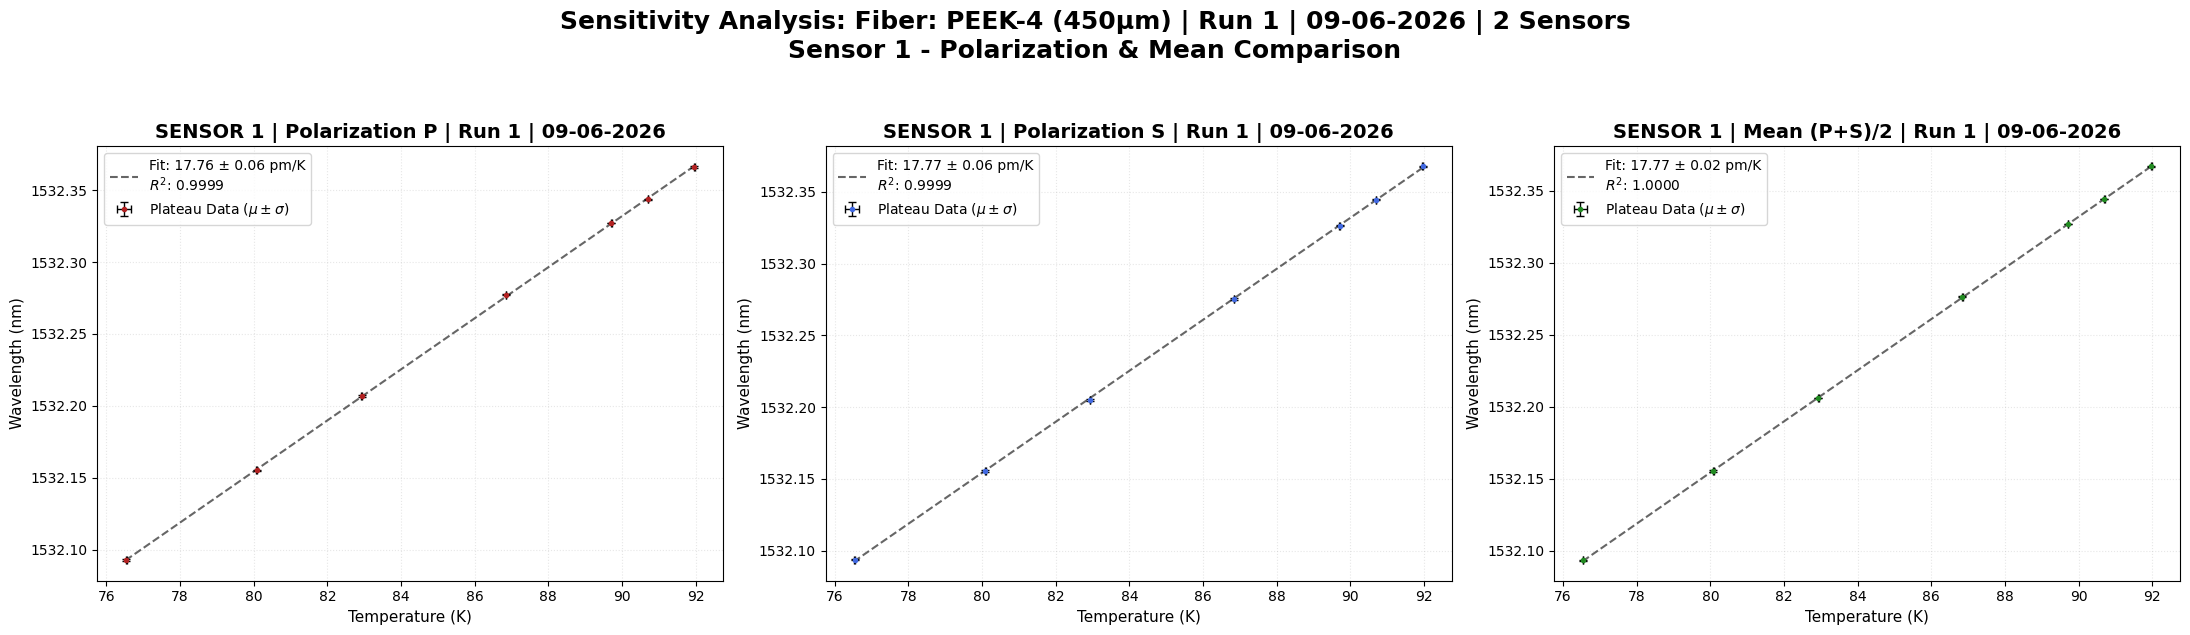

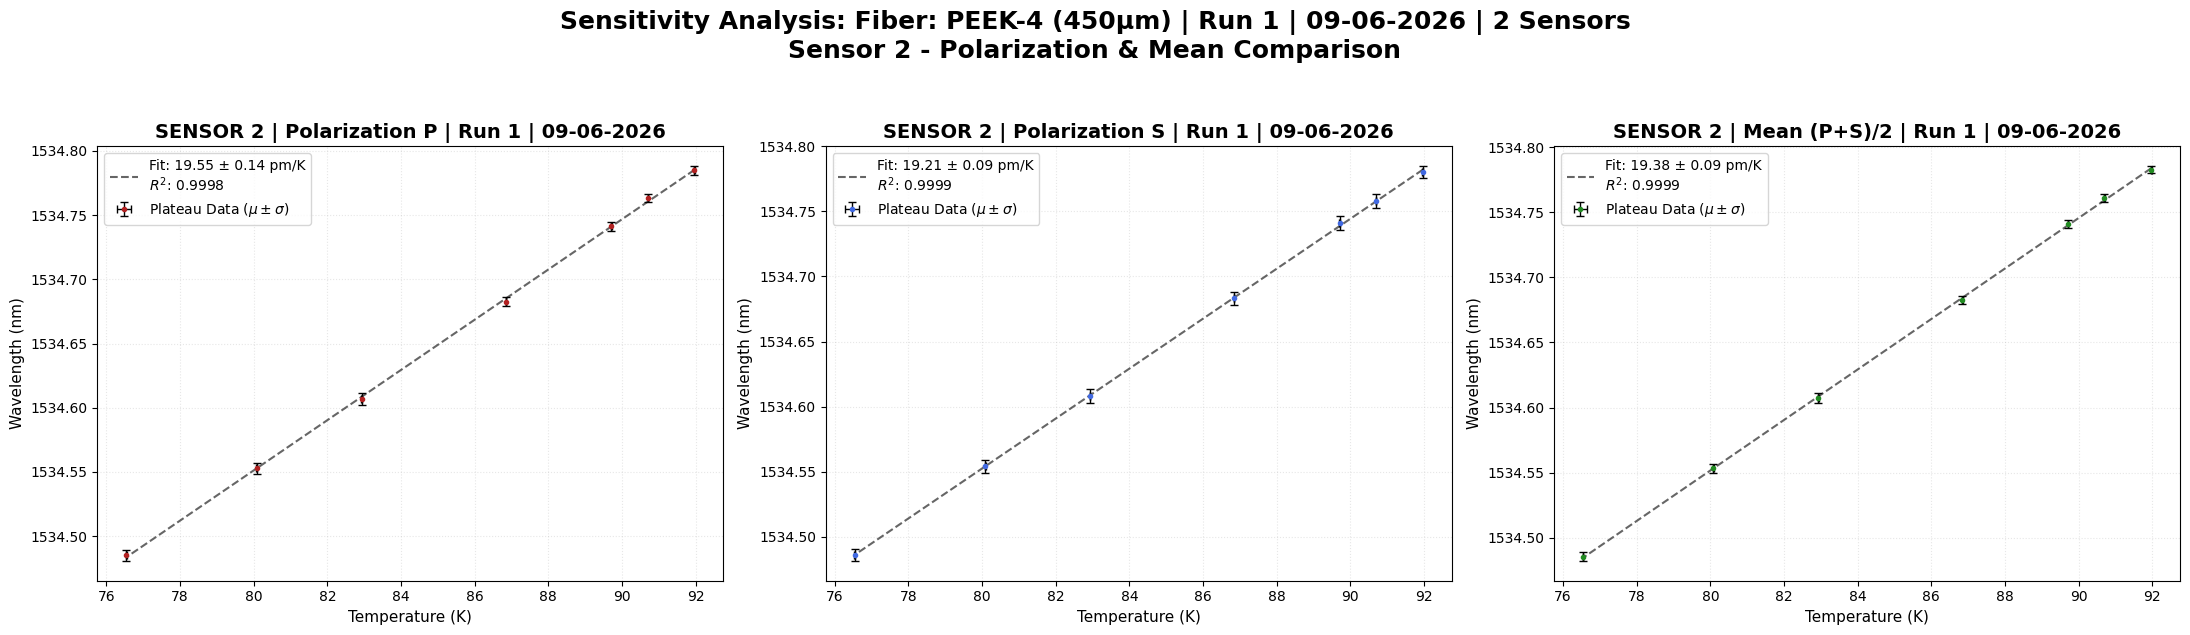


                  SENSITIVITY SUMMARY TABLE: FIBER PEEK-4 (RUN 1, 09-06-2026)                  
Sensor ID    | Measurement Type     | Slope (pm/K)       | Error (pm/K)    | R²      
-----------------------------------------------------------------------------------------------
Sensor 1     | Polarization P       |       17.760       |        0.060    | 0.9999
Sensor 1     | Polarization S       |       17.771       |        0.057    | 0.9999
Sensor 1     | Mean (P+S)/2         |       17.765       |        0.023    | 1.0000
Sensor 2     | Polarization P       |       19.550       |        0.136    | 0.9998
Sensor 2     | Polarization S       |       19.207       |        0.088    | 0.9999
Sensor 2     | Mean (P+S)/2         |       19.379       |        0.092    | 0.9999


In [19]:
# ============================================================================
# FINAL SENSITIVITY ANALYSIS: Fiber PEEK-7 | 2 Sensors | 27-02-2025
# Includes Slope Error in Legend, Summary Table and Explicit Sensor Labels
# ============================================================================

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# Data structure to store results for the final summary table
summary_results = []

# Fiber and Run information for titles
fiber_info = "Fiber: PEEK-4 (450µm) | Run 1 | 09-06-2026 | 2 Sensors"

for sensor_num in [1, 2]:
    # Create a separate figure for each sensor with 2 subplots (P, S, Mean)
    fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=False)
    
    plot_configs = [
        {"key": f"FBG-{sensor_num}-P", "title": "Polarization P", "color": "firebrick"},
        {"key": f"FBG-{sensor_num}-S", "title": "Polarization S", "color": "royalblue"},
        {"key": f"FBG-{sensor_num}-Mean", "title": "Mean (P+S)/2", "color": "forestgreen"}
    ]

    for idx, config in enumerate(plot_configs):
        ax = axes[idx]
        label = config["key"]
        
        t_means, t_stds, w_means, w_stds = [], [], [], []
        
        # 1. Collect statistics for each plateau
        if 'plateau_data' in globals() and len(plateau_data) > 0:
            for p in plateau_data:
                # Temperature stats (Horizontal Error)
                t_means.append(p["temp_mean"])
                t_stds.append(p["temp_std"])
                
                # Wavelength stats (Vertical Error)
                source = fbg_mean_data if "Mean" in label else fbg_filtered_data
                
                if label in source:
                    mask = (source[label]["timestamps"] >= p["t0"]) & \
                           (source[label]["timestamps"] <= p["tfin"])
                    wav_data = source[label]["wavelength"][mask]
                    
                    if len(wav_data) > 0:
                        w_means.append(np.mean(wav_data))
                        w_stds.append(np.std(wav_data))
                    else:
                        w_means.append(np.nan); w_stds.append(np.nan)
                else:
                    w_means.append(np.nan); w_stds.append(np.nan)

            # Convert to arrays and filter NaNs
            x = np.array(t_means); y = np.array(w_means)
            x_err = np.array(t_stds); y_err = np.array(w_stds)
            
            mask_valid = ~np.isnan(x) & ~np.isnan(y)
            x, y, x_err, y_err = x[mask_valid], y[mask_valid], x_err[mask_valid], y_err[mask_valid]

            if len(x) > 1:
                # 2. Linear Regression and Slope Error calculation
                slope, intercept, r_val, p_val, std_err = stats.linregress(x, y)
                
                # Convert results to pm/K for standard reporting
                slope_pm = slope * 1e3
                err_pm = std_err * 1e3
                
                # Store data for the final summary table
                summary_results.append({
                    "Sensor": f"Sensor {sensor_num}",
                    "Type": config["title"],
                    "Slope": slope_pm,
                    "Error": err_pm,
                    "R2": r_val**2
                })

                # 3. Plotting with Error Bars
                ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='o', color=config["color"], 
                            ecolor='black', elinewidth=1, markersize=3, capsize=3, label='Plateau Data ($\mu \pm \sigma$)')
                
                # Plot Regression Line
                ax.plot(x, slope*x + intercept, color='black', linestyle='--', alpha=0.6,
                        label=f'Fit: {slope_pm:.2f} ± {err_pm:.2f} pm/K\n$R^2$: {r_val**2:.4f}')

                # 4. SUBPLOT TITLES: Explicit Sensor Identification
                ax.set_title(f"SENSOR {sensor_num} | {config['title']} | Run 1 | 09-06-2026", fontsize=14, fontweight='bold')
                
                # Labels and Style
                ax.set_xlabel("Temperature (K)", fontsize=11)
                ax.set_ylabel("Wavelength (nm)", fontsize=11)
                ax.legend(fontsize=10, loc='best')
                ax.grid(True, alpha=0.3, linestyle=':')
                ax.ticklabel_format(useOffset=False, axis='y')

    # Main Title for the whole sensor figure
    plt.suptitle(f"Sensitivity Analysis: {fiber_info}\nSensor {sensor_num} - Polarization & Mean Comparison", 
                 fontsize=18, y=1.05, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ============================================================================
# FINAL SUMMARY TABLE: Results in pm/K
# ============================================================================
print("\n" + "="*95)
print(f"{'SENSITIVITY SUMMARY TABLE: FIBER PEEK-4 (RUN 1, 09-06-2026)':^95}")
print("="*95)
print(f"{'Sensor ID':<12} | {'Measurement Type':<20} | {'Slope (pm/K)':<18} | {'Error (pm/K)':<15} | {'R²':<8}")
print("-" * 95)
for res in summary_results:
    print(f"{res['Sensor']:<12} | {res['Type']:<20} | {res['Slope']:>12.3f}       | {res['Error']:>12.3f}    | {res['R2']:.4f}")
print("="*95)

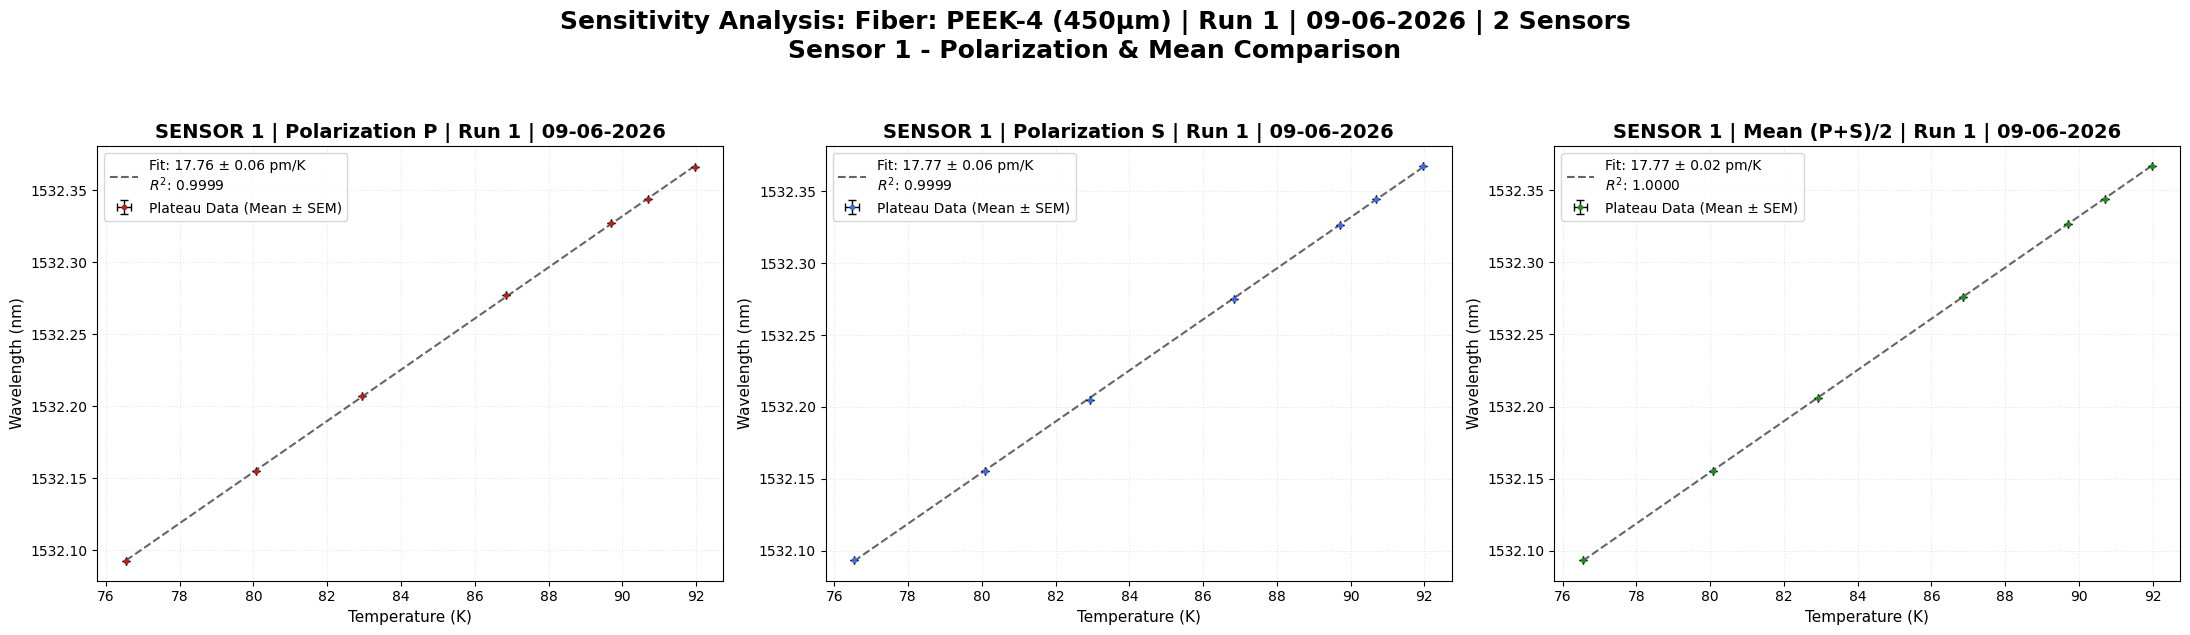

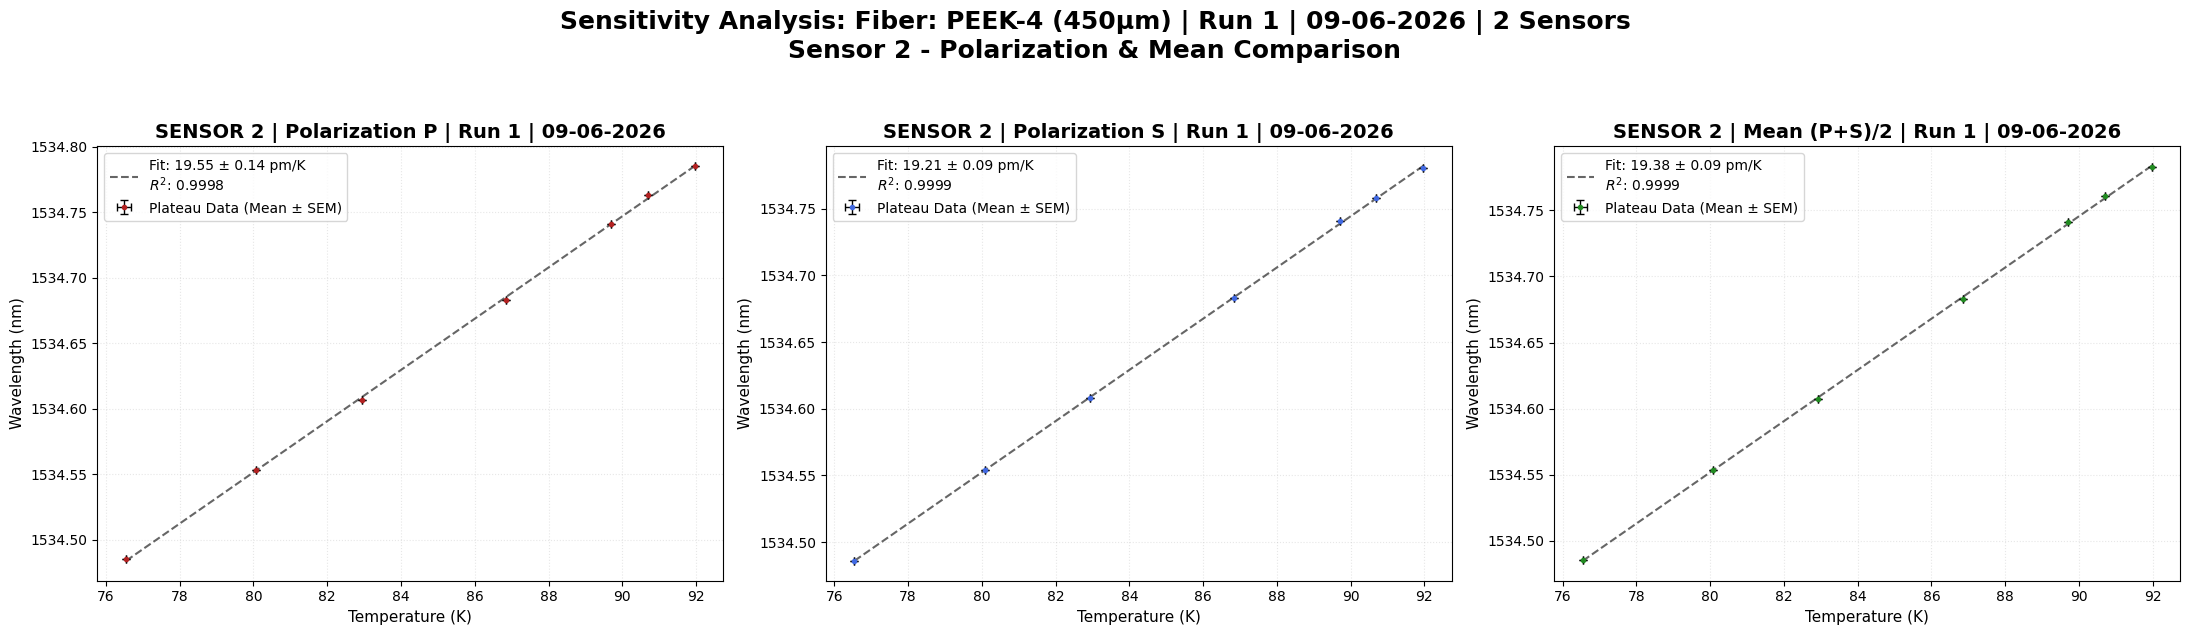


                  SENSITIVITY SUMMARY TABLE: FIBER PEEK-4 (RUN 1, 09-06-2026)                  
Sensor ID    | Measurement Type     | Slope (pm/K)       | Error (pm/K)    | R²      
-----------------------------------------------------------------------------------------------
Sensor 1     | Polarization P       |       17.760       |        0.060    | 0.9999
Sensor 1     | Polarization S       |       17.771       |        0.057    | 0.9999
Sensor 1     | Mean (P+S)/2         |       17.765       |        0.023    | 1.0000
Sensor 2     | Polarization P       |       19.550       |        0.136    | 0.9998
Sensor 2     | Polarization S       |       19.207       |        0.088    | 0.9999
Sensor 2     | Mean (P+S)/2         |       19.379       |        0.092    | 0.9999


In [20]:
# ============================================================================
# FINAL SENSITIVITY ANALYSIS: Fiber PEEK-7 | 2 Sensors | 27-02-2025
# Includes Slope Error in Legend, Summary Table and Explicit Sensor Labels
# UPDATED: Error bars now represent Standard Error of the Mean (SEM)
# ============================================================================

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# Data structure to store results for the final summary table
summary_results = []

# Fiber and Run information for titles
fiber_info = "Fiber: PEEK-4 (450µm) | Run 1 | 09-06-2026 | 2 Sensors"

for sensor_num in [1, 2]:
    # Create a separate figure for each sensor with 3 subplots (P, S, Mean)
    fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=False)
    
    plot_configs = [
        {"key": f"FBG-{sensor_num}-P", "title": "Polarization P", "color": "firebrick"},
        {"key": f"FBG-{sensor_num}-S", "title": "Polarization S", "color": "royalblue"},
        {"key": f"FBG-{sensor_num}-Mean", "title": "Mean (P+S)/2", "color": "forestgreen"}
    ]

    for idx, config in enumerate(plot_configs):
        ax = axes[idx]
        label = config["key"]
        
        t_means, t_stds, w_means, w_stds = [], [], [], []
        
        # 1. Collect statistics for each plateau
        if 'plateau_data' in globals() and len(plateau_data) > 0:
            for p in plateau_data:
                source = fbg_mean_data if "Mean" in label else fbg_filtered_data
                
                # Extract wavelength data first to know the sample size (N) for SEM
                if label in source:
                    mask = (source[label]["timestamps"] >= p["t0"]) & \
                           (source[label]["timestamps"] <= p["tfin"])
                    wav_data = source[label]["wavelength"][mask]
                    n_samples = len(wav_data)
                    
                    if n_samples > 1: # SEM calculation requires at least 2 points
                        w_means.append(np.mean(wav_data))
                        w_stds.append(stats.sem(wav_data)) # Vertical Error (SEM)
                    else:
                        w_means.append(np.nan)
                        w_stds.append(np.nan)
                else:
                    n_samples = 1
                    w_means.append(np.nan)
                    w_stds.append(np.nan)

                # Temperature stats (Horizontal Error) -> Converted to SEM
                t_means.append(p["temp_mean"])
                t_stds.append(p["temp_std"] / np.sqrt(n_samples) if n_samples > 0 else np.nan)

            # Convert to arrays and filter NaNs
            x = np.array(t_means); y = np.array(w_means)
            x_err = np.array(t_stds); y_err = np.array(w_stds)
            
            mask_valid = ~np.isnan(x) & ~np.isnan(y)
            x, y, x_err, y_err = x[mask_valid], y[mask_valid], x_err[mask_valid], y_err[mask_valid]

            if len(x) > 1:
                # 2. Linear Regression and Slope Error calculation
                slope, intercept, r_val, p_val, std_err = stats.linregress(x, y)
                
                # Convert results to pm/K for standard reporting
                slope_pm = slope * 1e3
                err_pm = std_err * 1e3
                
                # Store data for the final summary table
                summary_results.append({
                    "Sensor": f"Sensor {sensor_num}",
                    "Type": config["title"],
                    "Slope": slope_pm,
                    "Error": err_pm,
                    "R2": r_val**2
                })

                # 3. Plotting with Error Bars (Updated Legend to SEM)
                ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='o', color=config["color"], 
                            ecolor='black', elinewidth=1, markersize=3, capsize=3, label='Plateau Data (Mean ± SEM)')
                
                # Plot Regression Line
                ax.plot(x, slope*x + intercept, color='black', linestyle='--', alpha=0.6,
                        label=f'Fit: {slope_pm:.2f} ± {err_pm:.2f} pm/K\n$R^2$: {r_val**2:.4f}')

                # 4. SUBPLOT TITLES: Explicit Sensor Identification
                ax.set_title(f"SENSOR {sensor_num} | {config['title']} | Run 1 | 09-06-2026", fontsize=14, fontweight='bold')
                
                # Labels and Style
                ax.set_xlabel("Temperature (K)", fontsize=11)
                ax.set_ylabel("Wavelength (nm)", fontsize=11)
                ax.legend(fontsize=10, loc='best')
                ax.grid(True, alpha=0.3, linestyle=':')
                ax.ticklabel_format(useOffset=False, axis='y')

    # Main Title for the whole sensor figure
    plt.suptitle(f"Sensitivity Analysis: {fiber_info}\nSensor {sensor_num} - Polarization & Mean Comparison", 
                 fontsize=18, y=1.05, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ============================================================================
# FINAL SUMMARY TABLE: Results in pm/K
# ============================================================================
print("\n" + "="*95)
print(f"{'SENSITIVITY SUMMARY TABLE: FIBER PEEK-4 (RUN 1, 09-06-2026)':^95}")
print("="*95)
print(f"{'Sensor ID':<12} | {'Measurement Type':<20} | {'Slope (pm/K)':<18} | {'Error (pm/K)':<15} | {'R²':<8}")
print("-" * 95)
for res in summary_results:
    print(f"{res['Sensor']:<12} | {res['Type']:<20} | {res['Slope']:>12.3f}       | {res['Error']:>12.3f}    | {res['R2']:.4f}")
print("="*95)

## 7️⃣ Evolución Temporal Completa (Todo el rango con TIME_SHIFT aplicado)

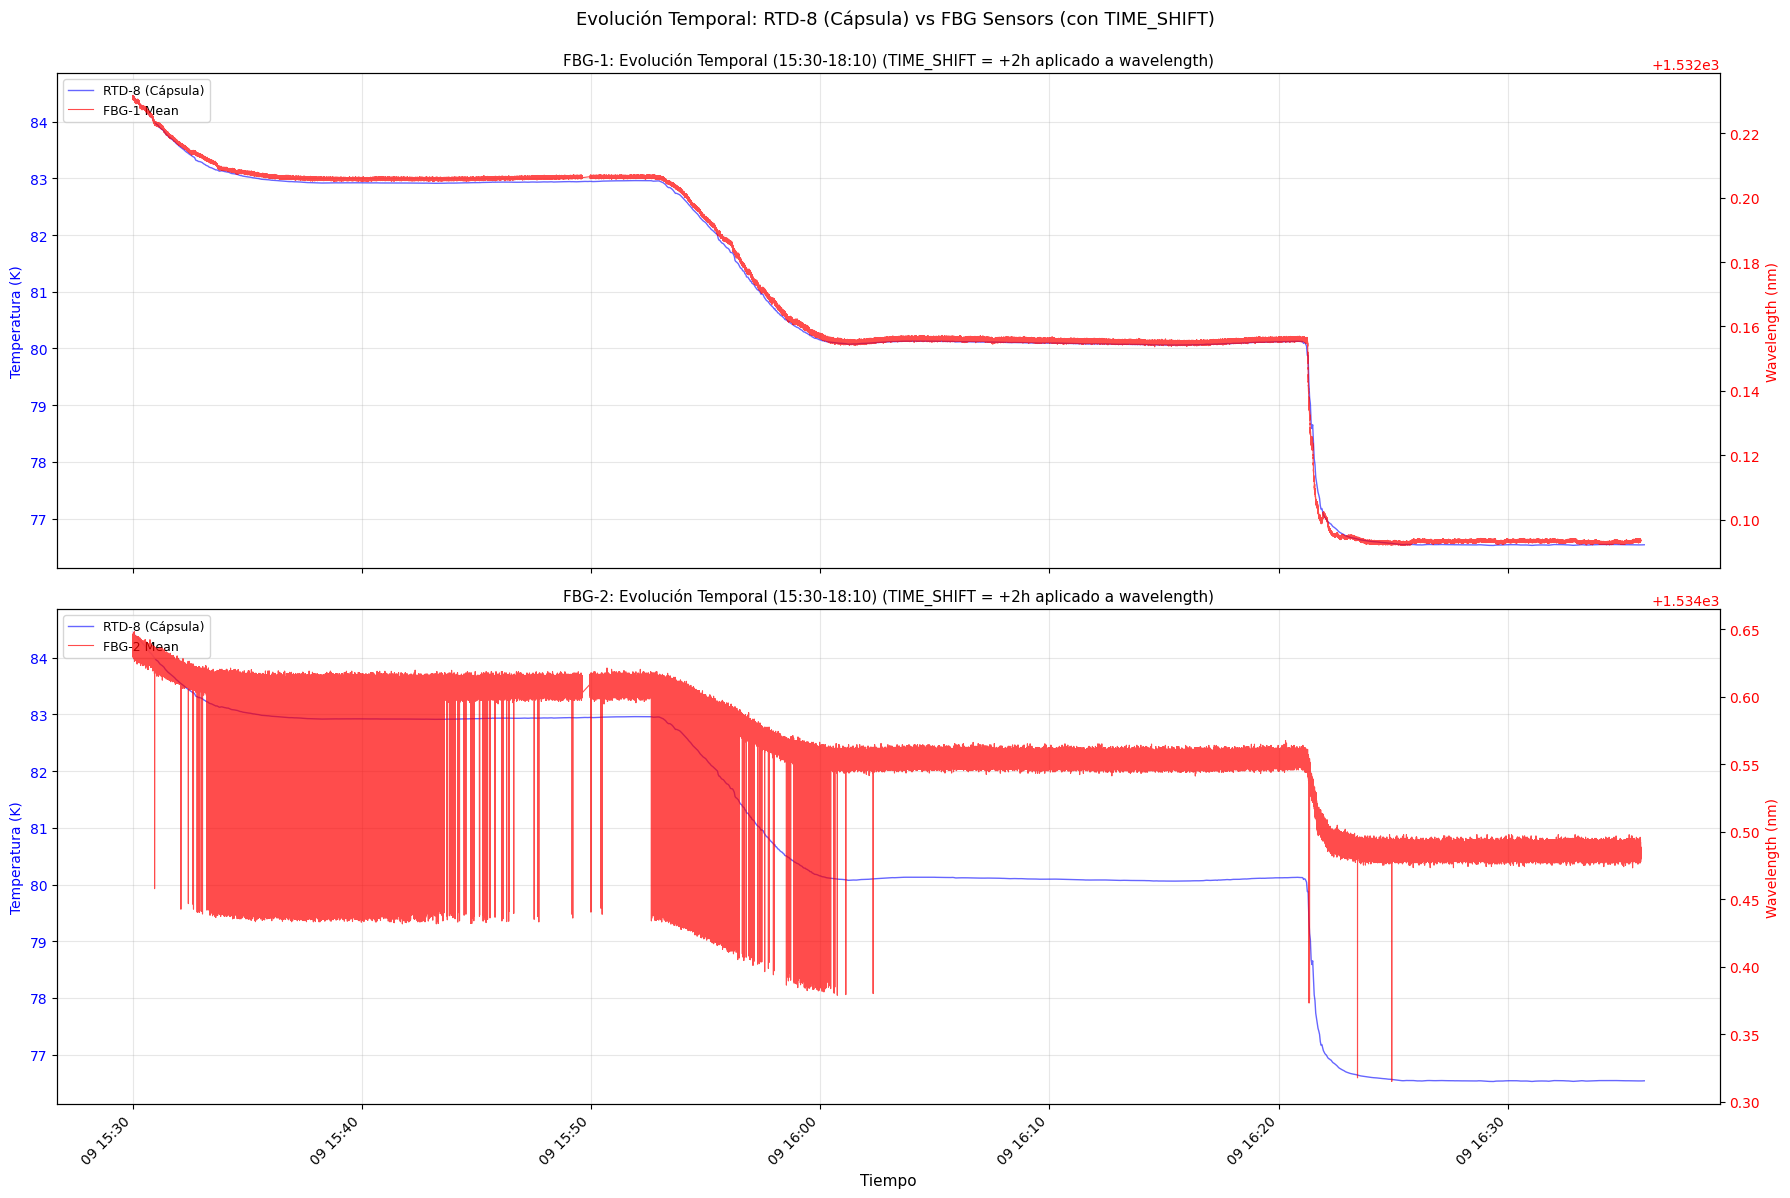


📊 Rango temporal mostrado: (15:30-18:10)
   Temperatura: 2026-06-09 15:30 - 16:35
   Wavelength (con +2h shift): 2026-06-09 15:30 - 16:35

💡 Este gráfico muestra el TIME_SHIFT de 2 horas aplicado a los datos de wavelength
   para alinearlos temporalmente con la temperatura.

⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'


In [21]:
# ============================================================================
# CONFIGURACIÓN: Filtrar por rango temporal (opcional)
# ============================================================================
# Opción A: Mostrar TODO el rango temporal disponible
use_filtered_range_plot = True  # Cambiar a True para filtrar por un rango específico

if use_filtered_range_plot:
    # Opción B: Definir rango específico para visualización
    # Puedes usar el mismo rango de la Sección 3 o definir uno personalizado
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(15, 30))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(18, 10))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    # Mostrar todo el rango disponible
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Rango completo)"
# ============================================================================

fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

# Filtrar datos de temperatura según rango seleccionado
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & \
                       (times_temp >= t_plot_inicio) & \
                       (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

for idx, sensor_num in enumerate([1, 2]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    
    # Extraer datos RAW completos
    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # Polarización P
    wav_s_full = wav_raw[:, 1, sensor_idx]  # Polarización S
    
    # Filtrar valores positivos y por rango temporal
    mask_p = (wav_p_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    
    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)
    
    # Media (P+S)/2
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0
    
    ax = axes[idx]
    
    # Plot temperatura
    ax.plot(times_temp_plot, temp_plot, 'b-', linewidth=1.0, alpha=0.6, label=f'{rtd_ref_name}')
    ax.set_ylabel('Temperatura (K)', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True, alpha=0.3)
    
    # Plot wavelength en eje secundario
    ax2 = ax.twinx()
    ax2.plot(times_p_plot, wav_mean_plot, 'r-', linewidth=0.8, alpha=0.7, label=f'FBG-{sensor_num} Mean')
    ax2.set_ylabel('Wavelength (nm)', fontsize=10, color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # Leyenda combinada
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    ax.set_title(f'FBG-{sensor_num}: Evolución Temporal {range_label} (TIME_SHIFT = +{TIME_SHIFT.total_seconds()/3600:.0f}h aplicado a wavelength)', 
                 fontsize=11)

# Configurar eje X solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Evolución Temporal: {rtd_ref_name} vs FBG Sensors (con TIME_SHIFT)', 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

print(f"\n📊 Rango temporal mostrado: {range_label}")
print(f"   Temperatura: {times_temp_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_temp_plot[-1].strftime('%H:%M')}")
print(f"   Wavelength (con +{TIME_SHIFT.total_seconds()/3600:.0f}h shift): {times_p_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_p_plot[-1].strftime('%H:%M')}")
print(f"\n💡 Este gráfico muestra el TIME_SHIFT de {TIME_SHIFT.total_seconds()/3600:.0f} horas aplicado a los datos de wavelength")
print(f"   para alinearlos temporalmente con la temperatura.")
if use_filtered_range_plot:
    print(f"\n⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'")
else:
    print(f"\n⚙️  Para filtrar por rango temporal específico: cambia 'use_filtered_range_plot = True'")

## 8️⃣ Resumen Final

## 📝 Guía de Uso

### Pasos básicos:
1. **Celda 2**: Cambiar ruta del archivo ROOT
2. **Celda 3**: Ajustar rango horario si es necesario
3. **Celda 6.1**: Seleccionar RTD de referencia
4. **Celda 6.2**: Visualizar perfiles Temp-Wavelength para identificar plateaus
5. **Celda 6.3**: Definir plateaus manuales con intervalos temporales
6. **Ejecutar todo**: Run All

### Configuración:
- **RTD referencia**: Celda 6.1 → `rtd_ref_idx` (6 = RTD-6 "Cápsula")
- **Plateaus**: Celda 6.3 → editar `manual_plateaus` con intervalos estables
- **Rango temporal**: Celda 3 → `t_inicio`, `t_fin`

### Método de plateaus:
El análisis calcula sensibilidades usando **plateaus manuales**:
1. Identificar intervalos donde temperatura es estable (visualizar en 6.2)
2. Definir intervalos temporales en formato "HH:MM" (celda 6.3)
3. Calcular μ±σ de temperatura y wavelength en cada plateau
4. Sensibilidad = pendiente del ajuste lineal con barras de error

### Output:
- **Sección 5**: Gráficos de temperatura (8 RTDs) y wavelengths (FBG-1,2,3)
- **Sección 6.2**: Visualización Temp-Wavelength superpuesta
- **Sección 6.3-6.4**: Estadísticas de plateaus (μ±σ)
- **Sección 6.5**: Gráficos de sensibilidad con error bars y R²
- **Sección 8**: Resumen con sensibilidades en pm/K

### Ejemplo de plateaus:
```python
manual_plateaus = [
    ("Plateau 1", "16:55", "17:01"),
    ("Plateau 2", "17:05", "17:12"),
    ("Plateau 3", "17:16", "17:21"),
    ("Plateau 4", "17:26", "17:35"),
]
```

**Nota**: FBG-4 excluido por falla del sensor (status=0 en adquisición).

## 📊 **Plot: Espectro Individual en Tiempo Específico**

Visualiza el espectro completo de un sensor FBG en un instante temporal determinado. Útil para analizar la forma del pico, FWHM, y calidad de la medición.

📂 VERIFICANDO ESTRUCTURA DEL TREE DE ESPECTROS (PEEK-4, 09/06/2026)

✅ Tree 'spectrum' encontrado
   Ramas disponibles: ['t', 'wav']

📊 Estructura de datos:
   't': shape=(1, 2), dtype=float64
   'wav': shape=(1, 2, 1, 39200), dtype=float64

   Detalle de 'wav' (espectros completos):
      Shape: (1, 2, 1, 39200)
      → Dimensiones: (n_entries=1, dim1=2, dim2=1, n_points=39200)

   ⏰ Timestamps ('t'):
      Shape: (1, 2)
      Primeros valores: [1.7810058e+09 1.7810058e+09]

🔍 BUSCANDO EVENTO MÁS CERCANO AL TIEMPO OBJETIVO
   ✅ Usando timestamps de 'spectrum.t'
   Timestamps shape: (69, 2) → usando columna 0
   Tiempo objetivo:     2026-06-09 15:15:00
   Tiempo más cercano:  2026-06-09 13:52:18
   Diferencia:          4961.6 segundos
   Índice del evento:   68

📊 Datos cargados del tree 'spectrum':
   Shape raw: (1, 2, 1, 39200)
   → Estructura 4D detectada, extrayendo primera entrada: (2, 1, 39200)

📊 Datos del evento listo para procesar:
   Shape final: (2, 1, 39200)
   Tamaño total

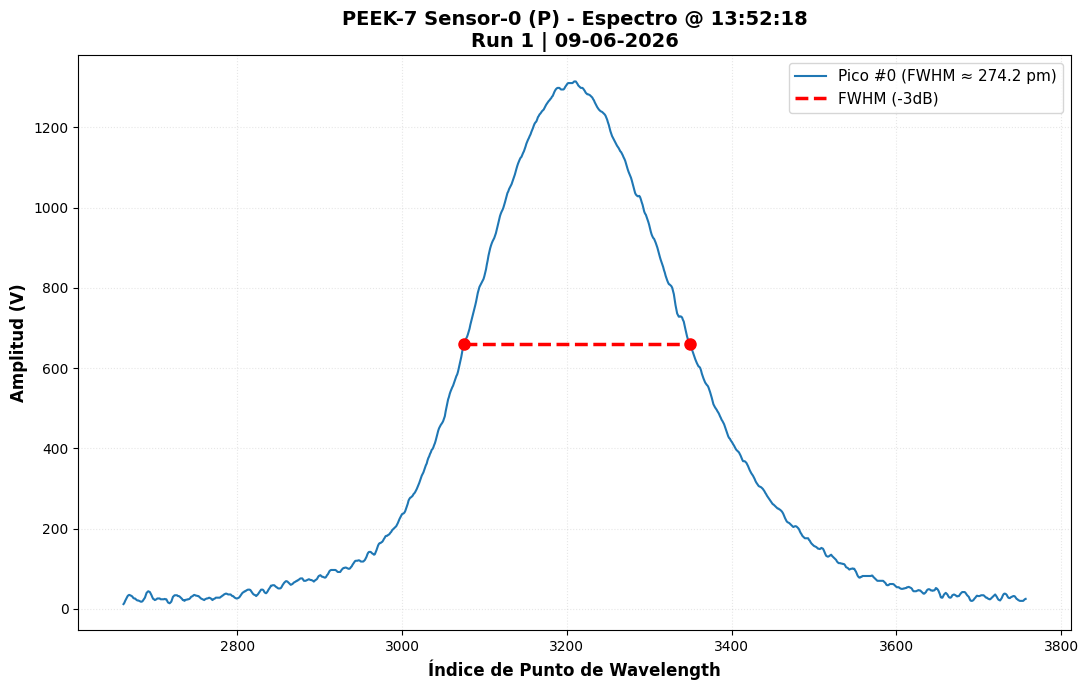


✅ Plot generado exitosamente


In [22]:
from scipy.signal import find_peaks, peak_widths

# ============================================================================
# CONFIGURACIÓN: ESPECTRO INDIVIDUAL
# ============================================================================

# ⏰ Tiempo a visualizar (aprox. en el primer plateau)
TARGET_TIME = datetime.datetime(2026, 6, 9, 15, 15, 0)  # Ajusta según tu necesidad

# 🔍 Selección de sensor y polarización
PLOT_SENSOR_IDX = 0   # Índice del sensor a visualizar
PLOT_POL_IDX = 0      # 0=P, 1=S
PLOT_PEAK_IDX = 0     # Si hay múltiples picos, cuál visualizar

POL_NAMES = {0: 'P', 1: 'S'}
PLOT_POL = POL_NAMES[PLOT_POL_IDX]

# ============================================================================
# PASO 1: Verificar estructura del tree 'spectrum' en el archivo ROOT
# ============================================================================

print("="*80)
print("📂 VERIFICANDO ESTRUCTURA DEL TREE DE ESPECTROS (PEEK-4, 09/06/2026)")
print("="*80)

try:
    with uproot.open(filepath) as file:
        # Verificar que existe el tree 'spectrum'
        if 'spectrum' in file:
            spectrum_tree = file['spectrum']
            print(f"\n✅ Tree 'spectrum' encontrado")
            print(f"   Ramas disponibles: {spectrum_tree.keys()}")
            
            # Leer una muestra pequeña
            sample = spectrum_tree.arrays(library="np", entry_stop=1)
            
            print(f"\n📊 Estructura de datos:")
            for key in sample.keys():
                data = sample[key]
                if hasattr(data, 'shape'):
                    print(f"   '{key}': shape={data.shape}, dtype={data.dtype}")
                else:
                    print(f"   '{key}': {type(data)}")
            
            # Verificar estructura de 'wav' (espectros)
            if 'wav' in sample:
                wav_sample = sample['wav']
                if hasattr(wav_sample, 'shape'):
                    print(f"\n   Detalle de 'wav' (espectros completos):")
                    print(f"      Shape: {wav_sample.shape}")
                    if wav_sample.ndim == 4:
                        print(f"      → Dimensiones: (n_entries={wav_sample.shape[0]}, "
                              f"dim1={wav_sample.shape[1]}, dim2={wav_sample.shape[2]}, n_points={wav_sample.shape[3]})")
                    elif wav_sample.ndim == 3:
                        print(f"      → Dimensiones: (n_entries={wav_sample.shape[0]}, "
                              f"dim1={wav_sample.shape[1]}, n_points={wav_sample.shape[2]})")
                    elif wav_sample.ndim == 2:
                        print(f"      → Dimensiones: (dim0={wav_sample.shape[0]}, n_points={wav_sample.shape[1]})")
            
            # Verificar timestamps
            if 't' in sample:
                t_sample = sample['t']
                if hasattr(t_sample, 'shape'):
                    print(f"\n   ⏰ Timestamps ('t'):")
                    print(f"      Shape: {t_sample.shape}")
                    if len(t_sample) > 0:
                        print(f"      Primeros valores: {t_sample.flat[:3]}")
                    else:
                        print(f"      (vacío - se usarán timestamps de 'peak')")
        else:
            print(f"\n❌ Tree 'spectrum' NO encontrado en el archivo ROOT")
            print(f"   Trees disponibles: {file.keys()}")

except Exception as e:
    print(f"\n❌ Error verificando estructura: {e}")

print("="*80)

# ============================================================================
# PASO 2: Cargar datos y encontrar el evento más cercano al tiempo objetivo
# ============================================================================

print("\n🔍 BUSCANDO EVENTO MÁS CERCANO AL TIEMPO OBJETIVO")
print("="*80)

wav_data = None
spectrum = None
center_idx = None
closest_time = None

try:
    with uproot.open(filepath) as file:
        if 'spectrum' not in file:
            print("❌ No hay tree 'spectrum' disponible en este archivo")
        else:
            spectrum_tree = file['spectrum']
            
            # Intentar obtener timestamps - pueden estar en spectrum o en peak
            timestamps_raw = None
            
            try:
                timestamps_raw = spectrum_tree['t'].array(library="np")
                if len(timestamps_raw) == 0:
                    timestamps_raw = None
                else:
                    print("   ✅ Usando timestamps de 'spectrum.t'")
            except:
                pass
            
            if timestamps_raw is None:
                print("   ℹ️  'spectrum.t' vacío o no disponible, usando timestamps de 'peak.t'")
                if 'peak' in file:
                    timestamps_raw = file['peak']['t'].array(library="np")
                else:
                    raise ValueError("No hay timestamps disponibles")
            
            # Procesar según estructura (puede ser 1D o 2D)
            if timestamps_raw.ndim == 2:
                timestamps = timestamps_raw[:, 0]
                print(f"   Timestamps shape: {timestamps_raw.shape} → usando columna 0")
            elif timestamps_raw.ndim == 1:
                timestamps = timestamps_raw
                print(f"   Timestamps shape: {timestamps_raw.shape}")
            else:
                print(f"   ⚠️  Estructura inesperada de timestamps: shape={timestamps_raw.shape}")
                timestamps = timestamps_raw.flatten()
            
            if len(timestamps) == 0:
                raise ValueError("No hay timestamps válidos después del procesamiento")
            
            # Convertir TARGET_TIME a timestamp Unix
            target_timestamp = TARGET_TIME.timestamp()
            
            # Encontrar índice más cercano
            time_diffs = np.abs(timestamps - target_timestamp)
            closest_idx_time = np.argmin(time_diffs)
            closest_timestamp = timestamps[closest_idx_time]
            closest_time = datetime.datetime.fromtimestamp(closest_timestamp)
            
            print(f"   Tiempo objetivo:     {TARGET_TIME.strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"   Tiempo más cercano:  {closest_time.strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"   Diferencia:          {abs(closest_timestamp - target_timestamp):.1f} segundos")
            print(f"   Índice del evento:   {closest_idx_time}")
            
            # Cargar el evento específico del tree 'spectrum'
            wav_data_raw = spectrum_tree['wav'].array(library="np", entry_start=closest_idx_time, entry_stop=closest_idx_time+1)
            
            print(f"\n📊 Datos cargados del tree 'spectrum':")
            print(f"   Shape raw: {wav_data_raw.shape}")
            
            # Verificar si hay datos
            if wav_data_raw.size == 0:
                print(f"\n   ⚠️  El tree 'spectrum' contiene datos pero están vacíos")
                raise ValueError("Tree 'spectrum' sin datos útiles")
            
            # Procesar según estructura
            if wav_data_raw.ndim == 4:
                wav_data = wav_data_raw[0]
                print(f"   → Estructura 4D detectada, extrayendo primera entrada: {wav_data.shape}")
            elif wav_data_raw.ndim == 3:
                wav_data = wav_data_raw[0]
                print(f"   → Estructura 3D detectada, extrayendo primera entrada: {wav_data.shape}")
            elif wav_data_raw.ndim == 2:
                wav_data = wav_data_raw
                print(f"   → Estructura 2D detectada: {wav_data.shape}")
            else:
                wav_data = wav_data_raw
                print(f"   → Estructura {wav_data_raw.ndim}D, usando como está")
            
            print(f"\n📊 Datos del evento listo para procesar:")
            print(f"   Shape final: {wav_data.shape}")
            print(f"   Tamaño total: {wav_data.size} elementos")
                
except Exception as e:
    print(f"\n❌ Error cargando eventos: {e}")
    import traceback
    traceback.print_exc()
    wav_data = None

# ============================================================================
# PASO 3: Extraer y visualizar el espectro seleccionado
# ============================================================================

if wav_data is not None and closest_time is not None:
    print(f"\n📈 EXTRAYENDO ESPECTRO")
    print("="*80)
    
    print(f"   Sensor Index:  {PLOT_SENSOR_IDX}")
    print(f"   Polarización:  {PLOT_POL}")
    print(f"   Tiempo:        {closest_time.strftime('%H:%M:%S')}")
    
    # Extraer espectro según estructura
    try:
        # Intentar diferentes estructuras
        if wav_data.ndim == 3:
            # Probar (sensores, pol, puntos)
            spectrum_full = wav_data[PLOT_SENSOR_IDX, PLOT_POL_IDX, :]
            print(f"   ✅ Espectro extraído (estructura 3D: sensor x pol x puntos)")
        elif wav_data.ndim == 2:
            # Probar (canales, puntos)
            ch = PLOT_SENSOR_IDX * 2 + PLOT_POL_IDX
            if ch < wav_data.shape[0]:
                spectrum_full = wav_data[ch, :]
                print(f"   ✅ Espectro extraído (estructura 2D, canal {ch})")
            else:
                # Si no hay suficientes canales, usar el índice como está
                spectrum_full = wav_data[PLOT_SENSOR_IDX, :]
                print(f"   ✅ Espectro extraído (estructura 2D, usando índice {PLOT_SENSOR_IDX})")
        elif wav_data.ndim == 1:
            spectrum_full = wav_data
            print(f"   ✅ Espectro 1D, usando directamente")
        else:
            raise ValueError(f"Estructura inesperada: {wav_data.ndim}D")
        
        # Diagnosticar
        print(f"   Puntos en espectro: {len(spectrum_full)}")
        print(f"   Rango de amplitud: [{np.nanmin(spectrum_full):.6e}, {np.nanmax(spectrum_full):.6e}]")
        n_nans = np.sum(np.isnan(spectrum_full))
        print(f"   NaN values: {n_nans}")
        
        # Detectar picos
        all_peaks, _ = find_peaks(spectrum_full, height=100, distance=500)
        print(f"\n   🔍 Picos detectados: {len(all_peaks)}")
        for i, peak_pos in enumerate(all_peaks[:5]):  # Mostrar primeros 5
            print(f"      Pico #{i}: posición {peak_pos}, amplitud {spectrum_full[peak_pos]:.1f}")
        if len(all_peaks) > 5:
            print(f"      ... ({len(all_peaks)-5} picos más)")
        
        # Seleccionar pico
        if len(all_peaks) > PLOT_PEAK_IDX:
            center_idx = all_peaks[PLOT_PEAK_IDX]
            print(f"\n   ✅ Pico #{PLOT_PEAK_IDX} seleccionado: posición {center_idx}")
        else:
            if len(all_peaks) > 0:
                center_idx = all_peaks[0]
                print(f"\n   ⚠️  PLOT_PEAK_IDX={PLOT_PEAK_IDX} fuera de rango. Usando primer pico.")
            else:
                center_idx = len(spectrum_full) // 2
                print(f"\n   ⚠️  No hay picos detectados. Usando centro del espectro.")
        
        spectrum = spectrum_full
        
    except Exception as e:
        print(f"   ❌ Error extrayendo espectro: {e}")
        import traceback
        traceback.print_exc()
        spectrum = None
        center_idx = None

print("="*80)

# ============================================================================
# PASO 4: Análisis y plotting del pico
# ============================================================================

if spectrum is not None and center_idx is not None and len(spectrum) > 0:
    print("\n🔬 ANALIZANDO PICO SELECCIONADO")
    print("="*80)
    
    print(f"   ✅ Pico en posición {center_idx} (amplitud: {spectrum[center_idx]:.1f})")
    
    # Calcular FWHM
    try:
        results_half = peak_widths(spectrum, [center_idx], rel_height=0.5)
        fwhm_points = results_half[0][0]
        fwhm_pm = fwhm_points * 1  # Asumiendo 1 pm por punto
        print(f"   📏 FWHM: {fwhm_pm:.1f} pm ({fwhm_points:.1f} puntos)")
    except:
        print(f"   ⚠️  No se pudo calcular FWHM")
        fwhm_points = 50
        fwhm_pm = 50
        results_half = None
    
    # Definir ventana alrededor del pico
    window = int(fwhm_points * 2)
    start_idx = max(center_idx - window, 0)
    end_idx = min(center_idx + window, len(spectrum))
    
    print(f"   📐 Ventana de visualización: índices [{start_idx}, {end_idx}]")
    
    x_pm = np.arange(start_idx, end_idx)
    y = spectrum[start_idx:end_idx]
    
    print("="*80)
    
    # ============================================================================
    # PLOT
    # ============================================================================
    
    fiber_name = f"PEEK-7 Sensor-{PLOT_SENSOR_IDX} ({PLOT_POL})"
    
    plt.figure(figsize=(11, 7))
    plt.plot(x_pm, y, linewidth=1.5, label=f"Pico #{PLOT_PEAK_IDX} (FWHM ≈ {fwhm_pm:.1f} pm)", color='#1f77b4')
    
    # Marcar FWHM
    if results_half is not None:
        # Extraer valores escalares (results_half retorna arrays, tomamos primer elemento)
        fwhm_height = results_half[1][0] if hasattr(results_half[1], '__len__') else results_half[1]
        fwhm_left = results_half[2][0] if hasattr(results_half[2], '__len__') else results_half[2]
        fwhm_right = results_half[3][0] if hasattr(results_half[3], '__len__') else results_half[3]
        
        plt.hlines(fwhm_height, fwhm_left, fwhm_right, 
                   color='red', linestyle='--', linewidth=2.5, label='FWHM (-3dB)')
        plt.plot([fwhm_left, fwhm_right], [fwhm_height, fwhm_height], 'ro', markersize=8)
    
    plt.xlabel("Índice de Punto de Wavelength", fontsize=12, fontweight='bold')
    plt.ylabel("Amplitud (V)", fontsize=12, fontweight='bold')
    if closest_time is not None:
        plt.title(f"{fiber_name} - Espectro @ {closest_time.strftime('%H:%M:%S')}\nRun 1 | 09-06-2026", 
                  fontsize=14, fontweight='bold')
    else:
        plt.title(f"{fiber_name} - Espectro\nRun 1 | 09-06-2026", fontsize=14, fontweight='bold')
    plt.legend(fontsize=11, loc='best')
    plt.grid(alpha=0.3, linestyle=':')
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Plot generado exitosamente")
else:
    print("\n❌ No se pudo generar el plot (espectro vacío o inválido)")